# 10b · 복소수 신경망(CVNN): 크기와 위상을 함께 나르는 뉴런

**이번 질문:** 마이크 여러 개에 같은 소리가 조금씩 늦게 도착하면, 각 마이크 신호는 크기는 같고 **위상**만 다릅니다. 실수 하나를 나르는 뉴런으로는 이 차이를 어떻게 다룰까요? 뉴런이 복소수를 나르면 무엇이 쉬워질까요?

10번은 노드 번호를 바꿔도 같은 답이 나오는지(순열 등변·불변)를, 05b번 4절은 입력을 옆으로 옮기면 특성 맵도 따라 옮겨지는지(이동 등변)를 확인했습니다. 이번에는 그 자리에 신호 전체의 위상을 한꺼번에 돌리는 변환 $z\mapsto e^{i\varphi}z$가 옵니다.
뉴런의 값과 가중치를 복소수로 바꾸고, 00번의 행렬곱·01번의 경사하강·03번의 backward·04번의 Adam이 복소수에서 어떻게 되는지 직접 계산합니다. 대부분은 그대로이고, 전치 자리에 켤레가 하나 더 붙습니다.

- 준비물: [00](../00_기초/00_math_to_numpy.ipynb) 4절의 `Z = X @ W + b`, [01](../00_기초/01_gradients_and_learning.ipynb) 3절의 중심차분과 6절의 갱신, [03](../00_기초/03_perceptron_to_mlp.ipynb) 5절의 backward, [04](../00_기초/04_optimizers.ipynb) 6절의 Adam, [10](10_gnn.ipynb) 5절의 등변·불변.
- 도착점: 복소 선형층과 modReLU의 forward·backward를 쓰고 실수부·허수부 중심차분으로 검산한 뒤, 마이크 8개의 신호로 소리가 온 방향 6개를 맞히는 복소 모델을 학습해 실수 MLP·크기만 쓰는 MLP·학습 없는 빔포머와 비교하고, 입력의 위상을 돌려도 예측이 그대로인지 확인합니다.
- 다음 연결: 기본 아키텍처 05–10b가 끝납니다. [11 선형대수](../02_연결/11_linear_algebra.ipynb)부터는 구조가 아니라 학습 목적과 표현을 다룹니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 복소수 곱은 "돌리고 늘리기"입니다. 그래서 복소 선형층 `Z = X @ W + b`를 실수부·허수부 좌표로 펼치면 가중치 하나마다 $2\times2$ 블록 $\begin{pmatrix}a&-b\\b&a\end{pmatrix}$만 허용된 실수 선형층이 되고(열벡터로 쓸 때의 모양. 이 노트북의 행 관례 `x @ R`에서는 전치 $\begin{pmatrix}a&b\\-b&a\end{pmatrix}$), 파라미터는 일반 실수층의 $4DK$개가 아니라 $2DK$개입니다.
2. 실수 손실을 줄이는 방향은 실수부·허수부의 편미분을 묶은 $g=\partial L/\partial x+i\,\partial L/\partial y=2\,\partial L/\partial\bar z$이고, 갱신은 `z -= lr * g`입니다. 선형층 backward는 전치 대신 켤레전치를 씁니다: `gW = X.conj().T @ gZ`, `gX = gZ @ W.conj().T`.
3. 복소평면 전체에서 미분 가능(정칙)하면서 유계인 함수는 상수뿐이라(Liouville), 실수에서 $(-1,1)$ 안에 머물던 $\tanh$도 복소수로 넓히면 극 $\pm i\pi/2$에서 발산합니다. 그래서 정칙을 포기하고 켜고 끄는 판단을 크기 $|z|$로만 하는 modReLU 같은 활성화를 씁니다. modReLU도 ReLU처럼 유계는 아니지만 모든 $z$에서 유한하고 위상을 그대로 둡니다. 편향 없는 복소층 + modReLU + $|\cdot|^2$ 읽기는 전체 위상 회전 $z\mapsto e^{i\varphi}z$에 **정확히** 불변입니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/cvnn_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src/utils/plotting.py").is_file())            # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(3·4절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 고정 MNIST 예시, 이 노트북의 그림 함수(src/utils/cvnn_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_examples
from src.utils.cvnn_plots import (
    plot_complex_multiply, plot_real_block, plot_magnitude_vs_phase, plot_phase_swap, plot_complex_descent,
    plot_tanh_blowup, plot_activation_fields, plot_doa_samples, plot_sample_curves, plot_phase_invariance,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· CVNN 준비 완료")

NumPy 2.4.6 · CVNN 준비 완료


### 📎 이 노트북의 예시: 마이크 8개의 신호, MNIST 7과 3의 푸리에 계수

- **마이크 8개의 신호.** 마이크 8개를 한 줄로 반 파장 간격으로 놓고, 한 주파수의 소리가 비스듬히(각도 $\alpha$) 들어온다고 합시다. 소리가 마이크마다 조금씩 늦게 도착하므로 마이크 $m$의 신호는 크기가 모두 같고 위상만 $m$에 비례해 달라집니다. 1–3절은 $\alpha=30°$에서 온 소리 하나로 손계산하고, 5절에서는 여섯 방향 중 어디서 왔는지 맞히는 분류 문제로 키웁니다.
- **MNIST 7과 3의 푸리에 계수.** 이미지도 여러 물결 무늬의 합으로 쓰면 무늬마다 계수 하나가 복소수(크기와 위상)입니다. 2절에서 "위상이 모양의 자리를 정한다"를 00번부터 쓴 고정 예시 7과 3으로 봅니다.

> **용어**
>
> - **복소수(complex number)** $z=x+iy$: 실수 두 개 $x$(**실수부**)와 $y$(**허수부**)를 묶은 수. $i^2=-1$입니다. 평면의 점 $(x, y)$, 곧 원점에서 나가는 화살표 하나로 그립니다. 코드에서는 `x + 1j * y`, 두 부분은 `z.real`, `z.imag`.
> - **절댓값(크기, magnitude)** $|z|=\sqrt{x^2+y^2}$: 화살표의 길이. 코드에서는 `np.abs(z)`.
> - **편각(위상, phase)** $\arg z$: 양의 실수축에서 화살표까지 잰 각도. 코드에서는 `np.angle(z)`, 범위는 $-\pi$부터 $\pi$까지(라디안).
> - **오일러 공식(Euler's formula)** $e^{i\theta}=\cos\theta+i\sin\theta$: 길이 1, 각도 $\theta$인 화살표. 그래서 $z=re^{i\theta}$(**극형식**, polar form)는 길이 $r$, 각도 $\theta$인 화살표입니다.
> - **주파수(frequency)** $f$: 진동이 1초에 몇 번 되풀이되는지(2절의 이미지 무늬에서는 이미지를 한 번 가로지르는 동안 몇 번 되풀이되는지). 한 번 진동이 화살표 한 바퀴라 1초에 도는 각도는 **각주파수** $\omega=2\pi f$(라디안)입니다.
> - **페이저(phasor)**: 한 주파수로 진동하는 신호 $A\cos(\omega t+\theta)$($t$는 시간)에서 시간에 따라 변하지 않는 크기 $A$와 위상 $\theta$만 남겨 복소수 $Ae^{i\theta}$ 하나로 적은 것. 실제 신호는 $\mathrm{Re}(Ae^{i\theta}e^{i\omega t})$로 되돌아갑니다. 소리가 늦게 도착하면 $\theta$만 바뀌고 $A$는 그대로입니다.
> - **파장(wavelength)** $\lambda$: 소리가 한 번 진동하는 동안 나아가는 거리. 경로가 $\lambda$만큼 길어지면 위상이 $2\pi$(한 바퀴) 달라집니다.
> - **MNIST**: 28×28 흑백 손글씨 숫자 70,000장과 정답 0–9. 값은 0(흰 종이)부터 1(진한 잉크)까지입니다. 이 노트북은 00번부터 쓴 고정 예시 10장 중 7과 3만 씁니다.

멀리서 온 소리는 파면(같은 순간에 같은 위상인 면)이 평평한 판처럼 다가옵니다. 소리의 진행 방향이 마이크 줄에 수직인 방향에서 $\alpha$만큼 기울어 있으면, 판이 이웃한 마이크에 닿으려면 마이크 간격을 진행 방향으로 잰 길이만큼 더 가야 합니다. $\alpha=0$(정면)이면 동시에 닿고, $\alpha=90°$(줄을 따라 옴)이면 간격 전체만큼 더 갑니다. 곧 이웃한 두 마이크까지의 경로 차이는 간격 $\times\sin\alpha=\frac{\lambda}{2}\sin\alpha$이고, 위상으로는 $2\pi\cdot\frac{1}{2}\sin\alpha=\pi\sin\alpha$입니다. 그래서 첫 마이크의 신호를 $s$라 하면

$$z_m=s\,e^{i\pi m\sin\alpha},\qquad m=0,1,\ldots,7.$$

마이크 번호가 하나 늘 때마다 같은 신호가 각도 $\pi\sin\alpha$만큼 돌아간 화살표가 됩니다. $\alpha=30°$이면 $\pi\sin\alpha=\pi/2$라 이웃마다 90°씩 돌고, 신호는 $s, is, -s, -is, \ldots$로 네 마이크마다 되풀이됩니다. 위상이 늘어나는 쪽을 양의 각도로 정한 것은 관례입니다.

아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `1j`: 파이썬의 허수 단위 $i$. `np.exp(1j * theta)`는 길이 1·각도 `theta`(라디안)인 복소수 $e^{i\theta}$이고, `0.8 * np.exp(1j * 0.5)`는 크기 0.8·위상 0.5 라디안인 복소수입니다.
> - `np.deg2rad(30)`: 도를 라디안으로($30\cdot\pi/180$). 계산은 라디안, 출력과 그림은 도로 적습니다.
> - `np.round(z, 3) + 0j`: 실수부·허수부를 소수 셋째 자리로 반올림합니다. `+ 0j`는 반올림으로 생긴 `-0.`을 `0.`으로 바꿔 출력을 읽기 쉽게 합니다.
> - `load_examples(download=True)`: 고정 예시 10장 `(10, 28, 28)`과 정답 `(10,)`. `mnist_examples[7]`이 숫자 7입니다.

In [2]:
mic_M = 8                                                          # 마이크 수
mic_m = np.arange(mic_M)                                           # (8,): 마이크 번호 0–7
mic_alpha = np.deg2rad(30)                                         # 소리가 들어온 각도 30° (라디안)
mic_s = 0.8 * np.exp(1j * 0.5)                                     # 첫 마이크의 신호: 크기 0.8, 위상 0.5 라디안
mic_z = mic_s * np.exp(1j * np.pi * mic_m * np.sin(mic_alpha))     # (8,) 복소: z_m = s·e^{iπ m sin α}
mnist_examples, mnist_labels = load_examples(download=True)        # (10, 28, 28), (10,)
mnist_7, mnist_3 = mnist_examples[7], mnist_examples[3]            # (28, 28) 두 장
print("마이크 신호 z_m:", np.round(mic_z, 3) + 0j)
print("z_m / s:", np.round(mic_z / mic_s, 3) + 0j)
print("예시 이미지", mnist_7.shape, mnist_3.shape, "· 정답", mnist_labels[7], mnist_labels[3])

마이크 신호 z_m: [ 0.702+0.384j -0.384+0.702j -0.702-0.384j  0.384-0.702j  0.702+0.384j
 -0.384+0.702j -0.702-0.384j  0.384-0.702j]
z_m / s: [ 1.+0.j  0.+1.j -1.+0.j  0.-1.j  1.+0.j  0.+1.j -1.+0.j  0.-1.j]
예시 이미지 (28, 28) (28, 28) · 정답 7 3


## 🔑 1. 복소수 하나는 화살표 하나: 곱은 회전과 확대입니다

**이 절에서 가져갈 것:** 극형식 $z=re^{i\theta}$에 $w=\rho e^{i\varphi}$를 곱하면 길이는 $\rho r$, 각도는 $\theta+\varphi$가 됩니다. 곱하기 한 번이 "돌리고 늘리기"라서, 복소 선형층 $Z=XW+b$를 실수부·허수부 좌표로 펼치면 가중치 하나마다 $2\times2$ 블록 $\begin{pmatrix}a&-b\\b&a\end{pmatrix}$만 허용된 실수 선형층이 됩니다(열벡터 관례. 아래 코드와 그림의 행 관례 `x @ R`에서는 전치 $\begin{pmatrix}a&b\\-b&a\end{pmatrix}$). 파라미터는 같은 크기 일반 실수층의 $4DK$개가 아니라 $2DK$개입니다.

마이크 신호에 증폭기를 달면 모든 마이크의 신호가 같은 비율로 커지고, 전선이 길어 조금 늦어지면 모든 위상이 같은 각도만큼 돕니다. 이 두 일을 한꺼번에 하는 것이 복소수 $w$ 하나를 곱하는 것입니다. 실수 뉴런의 가중치가 "얼마나 키울지"만 정했다면, 복소 뉴런의 가중치는 "얼마나 키우고 얼마나 돌릴지"를 함께 정합니다.

크기 $|z|$, 위상 $\arg z$, 극형식 $re^{i\theta}$는 📎 데이터 셀의 용어 상자에서 풀이했습니다.

> **용어**
>
> - **켤레(conjugate)** $\bar z=x-iy$: 허수부의 부호만 바꾼 것. 실수축에 비친 화살표입니다. $z\bar z=x^2+y^2=|z|^2$. 코드에서는 `z.conj()`.
> - **복소 선형층(complex linear layer)**: 00번 4절의 $Z=XW+b$에서 $X$, $W$, $b$가 복소수인 것. 식은 그대로이고 원소끼리의 곱만 복소수 곱입니다.

$$wz=\rho e^{i\varphi}\cdot re^{i\theta}=\rho r\,e^{i(\theta+\varphi)}.$$

곱하면 길이는 곱해지고 각도는 더해집니다. $e^{i\varphi}e^{i\theta}=e^{i(\theta+\varphi)}$이기 때문입니다.

같은 곱을 실수로 풀어 쓰면 $w=a+ib$, $z=x+iy$에서 $wz=(ax-by)+i(bx+ay)$이므로

$$\begin{pmatrix}\mathrm{Re}\,wz\\ \mathrm{Im}\,wz\end{pmatrix}=\begin{pmatrix}a&-b\\b&a\end{pmatrix}\begin{pmatrix}x\\y\end{pmatrix}=\rho\begin{pmatrix}\cos\varphi&-\sin\varphi\\ \sin\varphi&\cos\varphi\end{pmatrix}\begin{pmatrix}x\\y\end{pmatrix}.$$

복소수 곱은 "$\varphi$만큼 회전한 뒤 $\rho$배"인 실수 $2\times2$ 행렬이고, 네 칸이 아니라 두 숫자 $a, b$로 정해집니다.

층 전체에서는 $X:(N,D)$, $W:(D,K)$, $b:(K,)$가 복소수이고 $Z=XW+b:(N,K)$입니다. 입력을 실수 $(N, 2D)$로 펼칠 때 이 노트북은 **실수부와 허수부를 번갈아** 둡니다: $[\mathrm{Re}\,x_0, \mathrm{Im}\,x_0, \mathrm{Re}\,x_1, \mathrm{Im}\,x_1, \ldots]$. 그러면 펼친 실수 행렬 $R:(2D,2K)$는 $W_{dk}=a+ib$ 자리마다 $2\times2$ 블록 하나로 채워집니다. 00번의 행 관례(`x @ R`, 입력이 행)에서는 위 행렬의 전치 $\begin{pmatrix}a&b\\-b&a\end{pmatrix}$가 들어갑니다.

| | 복소 선형층 | 같은 크기의 일반 실수층 |
|---|---|---|
| 가중치의 실수 개수 | $2DK$ ($W$의 실수부·허수부) | $4DK$ ($R$의 모든 칸) |
| 가중치 블록 하나가 하는 일 | 돌리고 늘리기 | 아무 2×2 변환 (한 방향만 늘리기, 뒤집기도) |

아래는 $z=1+i$에 $w=\sqrt3+i$(길이 2, 각도 30°)를 곱하는 손계산과 화살표 네 개, 마이크 8개의 신호, 그리고 $D=4$, $K=3$인 복소 가중치를 실수로 펼친 행렬입니다.

> **코드**
>
> - `z.conj()`, `np.abs(z)`, `np.angle(z)`: 켤레·크기·위상(라디안). `np.rad2deg`로 도를 봅니다.
> - `f"{z:.4f}"`: 복소수를 실수부·허수부 각각 소수 넷째 자리까지 `0.7321+2.7321j`처럼 적습니다.
> - `R[0::2, 1::2] = W.imag`: `0::2`는 0부터 두 칸씩(짝수 번째), `1::2`는 1부터 두 칸씩(홀수 번째). 짝수 행(입력의 실수부)·홀수 열(출력의 허수부) 자리에 $W$의 허수부를 넣습니다.
> - `np.stack([Z.real, Z.imag], axis=-1).reshape(*Z.shape[:-1], -1)`: `(N, K)` 복소를 `(N, K, 2)` 실수로 쌓은 뒤 마지막 두 축을 이어 `(N, 2K)`로. 실수부·허수부가 번갈아 놓입니다. `*Z.shape[:-1]`은 마지막 축을 뺀 모양을 그대로 풀어 넣는 것이라 `(K,)`인 편향에도 같은 함수를 씁니다.

In [3]:
hand_z = 1 + 1j                                                    # 길이 √2, 각도 45°
hand_w = np.sqrt(3) + 1j                                           # 길이 2, 각도 30°
hand_wz = hand_w * hand_z                                          # 복소수 곱
hand_block = np.array([[hand_w.real, -hand_w.imag],
                       [hand_w.imag, hand_w.real]])                # (2, 2): 열벡터 관례의 [[a, −b], [b, a]]
hand_real = hand_block @ np.array([hand_z.real, hand_z.imag])      # (2,): 실수 행렬로 한 같은 곱
print(f"wz = {hand_wz:.4f} · 실수 2×2 행렬로: {hand_real}")
print(f"길이 {np.abs(hand_z):.4f} × {np.abs(hand_w):.4f} = {np.abs(hand_wz):.4f}"
      f" · 각도 {np.rad2deg(np.angle(hand_z)):.0f}° + {np.rad2deg(np.angle(hand_w)):.0f}° = {np.rad2deg(np.angle(hand_wz)):.0f}°")
arrow_z = np.array([1 + 1j, -0.6 + 0.9j, -0.9 - 0.4j, 0.7 - 0.6j])   # (4,): 화살표 네 개. 첫 번째가 손계산 z
arrow_wz = hand_w * arrow_z                                        # (4,): 모두 같은 w를 곱함
print("곱한 뒤 길이 / 곱하기 전 길이:", np.abs(arrow_wz) / np.abs(arrow_z))
print("곱한 뒤 각도 − 곱하기 전 각도 (도):", np.rad2deg(np.angle(arrow_wz * arrow_z.conj())))

wz = 0.7321+2.7321j · 실수 2×2 행렬로: [0.7321 2.7321]
길이 1.4142 × 2.0000 = 2.8284 · 각도 45° + 30° = 75°
곱한 뒤 길이 / 곱하기 전 길이: [2. 2. 2. 2.]
곱한 뒤 각도 − 곱하기 전 각도 (도): [30. 30. 30. 30.]


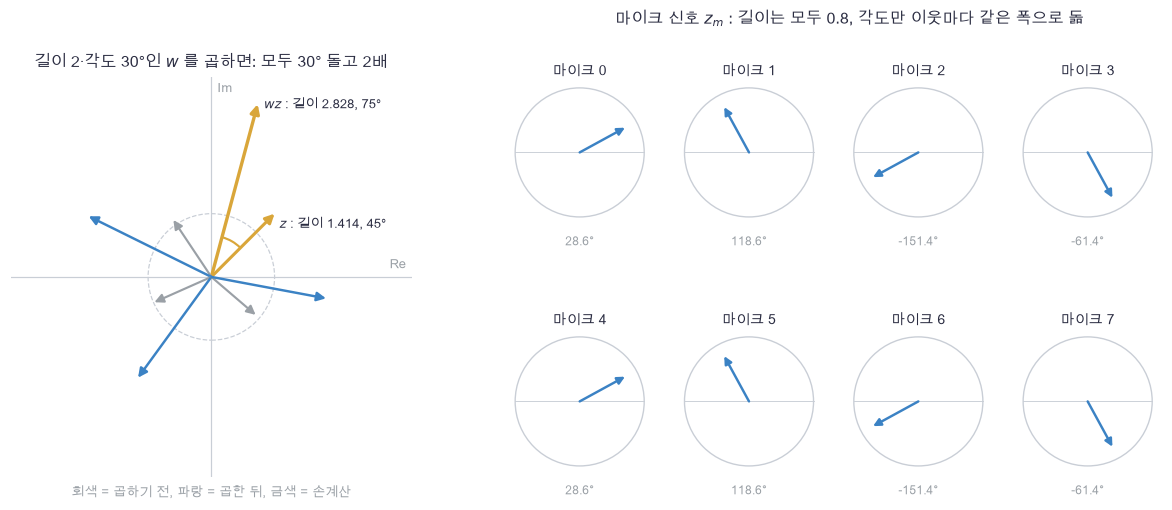

In [4]:
plot_complex_multiply(arrow_z, arrow_wz, hand_w, mic_z)

In [5]:
block_rng = np.random.default_rng(10)
block_W = np.round(block_rng.normal(size=(4, 3)) + 1j * block_rng.normal(size=(4, 3)), 1)   # (D=4, K=3) 복소 가중치 (소수 한 자리)
block_R = np.zeros((8, 6))                                         # (2D, 2K): 펼친 실수 행렬
block_R[0::2, 0::2] = block_W.real                                 # 입력 실수부 → 출력 실수부: a
block_R[0::2, 1::2] = block_W.imag                                 # 입력 실수부 → 출력 허수부: b
block_R[1::2, 0::2] = -block_W.imag                                # 입력 허수부 → 출력 실수부: −b
block_R[1::2, 1::2] = block_W.real                                 # 입력 허수부 → 출력 허수부: a
print("W[0, 0] =", block_W[0, 0], "→ 블록\n", block_R[:2, :2])

W[0, 0] = (-1.1-0.3j) → 블록
 [[-1.1 -0.3]
 [ 0.3 -1.1]]


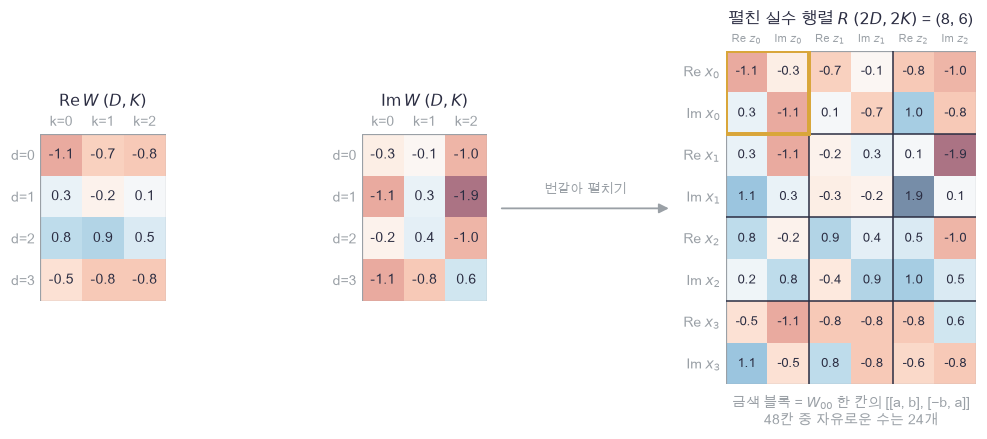

In [6]:
plot_real_block(block_W, block_R)

🔍 **확인** · 첫 그림의 회색 화살표 세 개와 금색 손계산 화살표 $z$, 곧 네 화살표가 모두 30° 돌고 두 배가 됩니다(출력의 길이 비 2, 각도 차 30°). 회색은 파란 화살표가 되고, 금색은 금색 $wz$가 됩니다. 금색 손계산은 길이 1.4142·45°인 $1+i$가 길이 2.8284·75°인 $0.7321+2.7321i$가 되는 것이고, 실수 $2\times2$ 행렬로 곱한 값과 같습니다. 오른쪽 시계 여덟 개는 마이크 신호입니다. 길이는 모두 0.8이고 각도만 28.6°, 118.6°, −151.4°, −61.4°로 90°씩 돕니다.
둘째 그림에서 펼친 $8\times6$ 행렬은 굵은 선으로 나눈 $2\times2$ 블록마다 대각선 두 칸이 같고($a$) 나머지 두 칸은 부호만 반대입니다($b$, $-b$). 48칸 중 자유롭게 정할 수 있는 수는 24개입니다. 아래 구현은 이 펼치기를 함수로 적고, 복소 행렬곱과 펼친 실수 행렬곱이 같은지 확인합니다.

In [7]:
def complex_linear(X, W, b):
    """복소 선형층 Z = XW + b (00번 4절과 같은 식). X: (N, D), W: (D, K), b: (K,) 복소 → Z: (N, K) 복소. @는 켤레를 취하지 않습니다."""
    return X @ W + b


def complex_to_real(Z):
    """복소 배열의 마지막 축을 실수부·허수부가 번갈아 놓인 실수로 펼칩니다. (..., K) 복소 → (..., 2K) 실수."""
    return np.stack([Z.real, Z.imag], axis=-1).reshape(*Z.shape[:-1], -1)


def real_block(W):
    """복소 가중치 W: (D, K)를 행 관례의 실수 행렬 R: (2D, 2K)로. complex_to_real(X @ W) = complex_to_real(X) @ R.
    W_dk = a + ib 자리마다 2×2 블록 [[a, b], [−b, a]]."""
    D, K = W.shape
    R = np.zeros((2 * D, 2 * K))
    R[0::2, 0::2] = W.real
    R[0::2, 1::2] = W.imag
    R[1::2, 0::2] = -W.imag
    R[1::2, 1::2] = W.real
    return R

In [8]:
# 쓰는 것: hand_w, hand_z, hand_wz (1절 손계산 셀) · block_W, block_R (1절 블록 셀)
lin_rng = np.random.default_rng(11)
lin_X = lin_rng.normal(size=(5, 4)) + 1j * lin_rng.normal(size=(5, 4))       # (N=5, D=4) 복소 입력
lin_b = lin_rng.normal(size=3) + 1j * lin_rng.normal(size=3)                 # (K=3,) 복소 편향
lin_Z = complex_linear(lin_X, block_W, lin_b)                                 # (5, 3) 복소
lin_Z_real = complex_to_real(lin_X) @ real_block(block_W) + complex_to_real(lin_b)   # (5, 6): 펼친 실수 선형층
np.testing.assert_allclose(complex_to_real(lin_Z), lin_Z_real)                # 검산: 복소 행렬곱 = 펼친 실수 행렬곱
np.testing.assert_allclose(real_block(block_W), block_R)                      # 검산: 위 그림의 R
hand_R = real_block(np.array([[hand_w]]))                                     # (2, 2): w 하나의 블록
np.testing.assert_allclose(hand_R, [[np.sqrt(3), 1], [-1, np.sqrt(3)]])       # 검산: 행 관례 블록 [[a, b], [−b, a]]
np.testing.assert_allclose(complex_to_real(np.array([hand_z])) @ hand_R, complex_to_real(np.array([hand_wz])))   # 검산: 손계산 곱
n_complex = 2 * block_W.size + 2 * lin_b.size                                 # 복소층의 실수 파라미터 2DK + 2K
n_real = real_block(block_W).size + 2 * lin_b.size                            # 일반 실수층 4DK + 2K
print(f"복소 행렬곱 = 펼친 실수 행렬곱 · 실수 파라미터 수: 복소층 {n_complex} (2DK + 2K), 일반 실수층 {n_real} (4DK + 2K)")
conj_R = np.array([[1., 0.], [0., -1.]])                                      # 켤레 z → z̄ 를 행 관례 실수 행렬로
conj_is_block = np.isclose(conj_R[0, 0], conj_R[1, 1]) and np.isclose(conj_R[0, 1], -conj_R[1, 0])
assert not conj_is_block, "켤레는 [[a, b], [−b, a]] 꼴이 아니어야 합니다 (대각선이 1, −1)"
print("켤레 [[1, 0], [0, −1]]을 복소수 w 하나의 곱으로 쓸 수 있나:", conj_is_block)

복소 행렬곱 = 펼친 실수 행렬곱 · 실수 파라미터 수: 복소층 30 (2DK + 2K), 일반 실수층 54 (4DK + 2K)
켤레 [[1, 0], [0, −1]]을 복소수 w 하나의 곱으로 쓸 수 있나: False


🔍 **확인** · 복소 행렬곱과 펼친 실수 행렬곱이 같고, 손계산 블록도 $\begin{pmatrix}\sqrt3&1\\-1&\sqrt3\end{pmatrix}$입니다. $D=4$, $K=3$에서 복소층의 실수 파라미터는 30개, 같은 입출력 폭의 일반 실수층은 54개입니다.
켤레 $z\mapsto\bar z$는 실수 좌표로는 선형이지만(행렬 $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$) 대각선 두 칸이 달라 어떤 $w$의 곱으로도 쓸 수 없습니다. 복소 선형층은 "뒤집기"를 할 수 없습니다. 대신 복소수 곱끼리는 순서를 바꿔도 같아서 $w\,(e^{i\varphi}z)=e^{i\varphi}\,(wz)$, 곧 입력 전체를 먼저 돌리나 곱한 뒤 돌리나 같습니다. 4절의 위상 등변이 여기서 나옵니다.

### ✏️ 연습 1 · 극형식으로 곱하기

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

길이 `r`·각도 `theta`인 $z$와 길이 `rho`·각도 `phi`인 $w$의 곱 $wz$를 **직교 좌표로 풀지 않고** 극형식 한 줄로 만드세요. 길이는 곱하고 각도는 더합니다. 각도는 라디안입니다.

In [9]:
def exercise_polar_product(r, theta, rho, phi):
    """연습 1: 극형식으로 곱하기. z = r e^{iθ}, w = ρ e^{iφ} (각도는 라디안, 숫자 또는 같은 모양의 배열) → wz (복소)."""
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 길이는 곱하고 각도는 더한 극형식 product = ρ·r·e^{i(θ + φ)}
    ### 힌트: 1절 수식 wz = ρr e^{i(θ+φ)} 한 줄입니다. e^{iθ}는 np.exp(1j * theta)
    raise NotImplementedError
    return product

In [10]:
def check_polar_product(candidate):
    """손계산 (√2, 45°)·(2, 30°)와 마이크 신호를 자기 각도만큼 되돌리기로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mic_z, mic_s (📎 데이터 셀)
    product = candidate(np.sqrt(2), np.deg2rad(45), 2.0, np.deg2rad(30))
    np.testing.assert_allclose(product, (np.sqrt(3) - 1) + (np.sqrt(3) + 1) * 1j)   # 검산: (√3 + i)(1 + i)
    np.testing.assert_allclose(np.abs(product), 2 * np.sqrt(2))                     # 검산: 길이 √2 · 2
    np.testing.assert_allclose(np.rad2deg(np.angle(product)), 75)                   # 검산: 각도 45° + 30°
    back = candidate(np.abs(mic_z), np.angle(mic_z), 1 / np.abs(mic_s), -np.angle(mic_z))   # (8,): 신호마다 자기 각도만큼 거꾸로, 1/|s|배
    np.testing.assert_allclose(back, np.ones(8), atol=1e-12)                        # 검산: 모두 길이 1, 각도 0
    print("극형식 곱: 길이는 곱하고 각도는 더합니다. 손계산과 일치합니다.")

run_check(check_polar_product, exercise_polar_product, hint="product = r * rho * np.exp(1j * (theta + phi))")

☐ exercise_polar_product: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: product = r * rho * np.exp(1j * (theta + phi))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
product = r * rho * np.exp(1j * (theta + phi))
```

</details>

## 🔑 2. 위상에 담긴 정보: 크기만 남기면 무엇을 잃나

**이 절에서 가져갈 것:** 마이크 신호의 크기 $|z_m|$는 소리가 어느 방향에서 왔든 모두 $|s|$라서, 크기만 보면 방향 정보가 없습니다. 방향은 이웃 마이크 사이의 위상 차이 $\pi\sin\alpha$에 들어 있습니다. 이미지의 푸리에 계수에서도 위상이 무늬의 **자리**를 정해, "7의 위상 + 3의 크기"로 되돌리면 7을 닮은 이미지가 나옵니다.

소리가 −30°, 0°, 30°, 50°에서 들어온 네 경우를 봅시다. 마이크마다 소리의 세기를 재는 계기판(크기)을 보면 네 경우 모두 여덟 마이크가 같은 값을 가리킵니다. 그런데 마이크 사이의 도착 시각 차이(위상 차이)는 방향마다 다릅니다. 실수 신경망에 크기만 넣으면 방향을 맞힐 수 없다는 뜻이고, 5절에서 실제로 학습해 확인합니다.

> **용어**
>
> - **위상 차이(phase difference)**: 두 복소수의 각도 차이 $\arg z_{m+1}-\arg z_m$. 한 바퀴를 넘지 않게 $\arg(z_{m+1}\bar z_m)$으로 계산합니다. 1절에서 곱하면 각도가 더해지고 켤레는 각도의 부호를 바꾸므로, $z_{m+1}\bar z_m$의 각도가 곧 두 각도의 차이입니다.
> - **푸리에 변환(Fourier transform)**: 신호를 여러 주파수의 물결 무늬의 합으로 나타내는 것. 28×28 이미지의 2차원 이산 푸리에 변환은 복소 계수 $F_{uv}$ 28×28개를 줍니다. 계수의 크기는 그 무늬가 얼마나 진한지, 위상은 무늬가 어느 쪽으로 밀려 있는지를 뜻합니다. 코드에서는 `np.fft.fft2`, 되돌리기는 `np.fft.ifft2`.
> - **Parseval 등식**: 변환 전후의 에너지(제곱합)가 같다는 것. NumPy `fft2`의 규약에서는 $\sum_{ij}x_{ij}^2=\frac{1}{HW}\sum_{uv}|F_{uv}|^2$입니다.

마이크 신호에서

$$|z_m|=|s|\,\big|e^{i\pi m\sin\alpha}\big|=|s|,\qquad z_{m+1}\bar z_m=|s|^2e^{i\pi\sin\alpha}\ \Rightarrow\ \alpha=\arcsin\!\left(\frac{\arg(z_{m+1}\bar z_m)}{\pi}\right).$$

크기에는 $\alpha$가 남아 있지 않고, 이웃끼리 곱한 값의 각도에는 $\pi\sin\alpha$가 그대로 남습니다. 첫 신호 $s$의 위상은 $s\bar s=|s|^2$에서 지워지므로, 소리가 언제 시작했는지 몰라도 방향을 읽을 수 있습니다. 간격을 반 파장으로 둔 이유도 여기 있습니다. 위상 차이 $\pi\sin\alpha$가 $-\pi$부터 $\pi$까지, 곧 반 바퀴를 넘지 않아 `np.angle`이 돌려주는 범위 안에 그대로 들어가므로, 양 끝 $\pm90°$를 빼면 $\alpha$가 하나로 정해집니다. 간격이 $\lambda$였다면 차이가 $2\pi\sin\alpha$라 $\alpha=30°$와 $-30°$가 둘 다 $\pm\pi$, 같은 각도가 되어 구별되지 않습니다.

같은 계산을 이미지에서 보면, 계수 $F=|F|e^{i\angle F}$의 크기와 위상을 두 이미지에서 따로 가져와

$$\tilde x=\mathrm{Re}\,\mathrm{ifft2}\big(|F_3|\,e^{i\angle F_7}\big)$$

를 만듭니다. $\tilde x$가 7을 닮으면 모양을 정한 쪽은 위상, 3을 닮으면 크기입니다.

> **코드**
>
> - `mic_m[None, :] * np.sin(...)[:, None]`: `(1, 8)`과 `(4, 1)`을 곱해 `(4, 8)`. 행이 방향, 열이 마이크입니다(00b번 3절의 브로드캐스팅).
> - `z[:, 1:] * z[:, :-1].conj()`: 행마다 이웃한 쌍 $(z_{m+1}, z_m)$ 7개를 한 번에 곱합니다. `.sum(axis=1)`로 7개를 더한 뒤 각도를 재면 잡음이 있을 때 평균 효과가 납니다.
> - `np.unique(a.round(12))`: 배열에 들어 있는 서로 다른 값을 작은 것부터 한 번씩. 소수 12자리로 반올림해 부동소수점 찌꺼기로 갈라진 값을 하나로 봅니다. 결과가 값 하나면 표 전체가 같은 값입니다.
> - `[f(ref) for ref in (mnist_7, mnist_3)]`: 리스트 컴프리헨션. 괄호 안의 두 이미지를 차례로 `ref`에 넣어 계산한 값 두 개의 목록 `[7과의 값, 3과의 값]`을 만듭니다.
> - `np.fft.fftshift(F)`: 그림에서 낮은 주파수를 가운데로 옮깁니다(값은 그대로, 자리만). `np.log1p(np.abs(F))`는 $\log(1+|F|)$로, 계수 크기의 차이가 너무 커서 그림에서 로그로 줄입니다.
> - `np.corrcoef(a.ravel(), b.ravel())[0, 1]`: 두 이미지를 한 줄로 편 뒤의 상관계수. 1에 가까울수록 밝고 어두운 자리가 닮았습니다.

In [11]:
# 쓰는 것: mic_m, mic_s (📎 데이터 셀)
phase_alpha_deg = np.array([-30, 0, 30, 50])                                       # (4,): 네 방향
phase_z = mic_s * np.exp(1j * np.pi * mic_m[None, :] * np.sin(np.deg2rad(phase_alpha_deg))[:, None])   # (4, 8)
phase_magnitude = np.abs(phase_z)                                                  # (4, 8): 크기
phase_deg = np.rad2deg(np.angle(phase_z))                                          # (4, 8): 위상 (도)
phase_step = np.angle(np.sum(phase_z[:, 1:] * phase_z[:, :-1].conj(), axis=1))   # (4,): 이웃 곱의 각도 = πsinα
phase_step = np.round(phase_step, 12) + 0.0                                      # 출력용: −1e−17 같은 반올림 찌꺼기와 −0을 0으로
phase_recovered = np.rad2deg(np.arcsin(phase_step / np.pi))                         # (4,): 되찾은 각도 (도)
print("크기 표의 서로 다른 값:", np.unique(phase_magnitude.round(12)))
print("방향별 위상의 한 행 (−30°):", phase_deg[0].round(1))
print("이웃 위상 차이 (도):", np.rad2deg(phase_step).round(1), "· 되찾은 각도 (도):", phase_recovered.round(1))

크기 표의 서로 다른 값: [0.8]
방향별 위상의 한 행 (−30°): [  28.6  -61.4 -151.4  118.6   28.6  -61.4 -151.4  118.6]
이웃 위상 차이 (도): [-90.    0.   90.  137.9] · 되찾은 각도 (도): [-30.   0.  30.  50.]


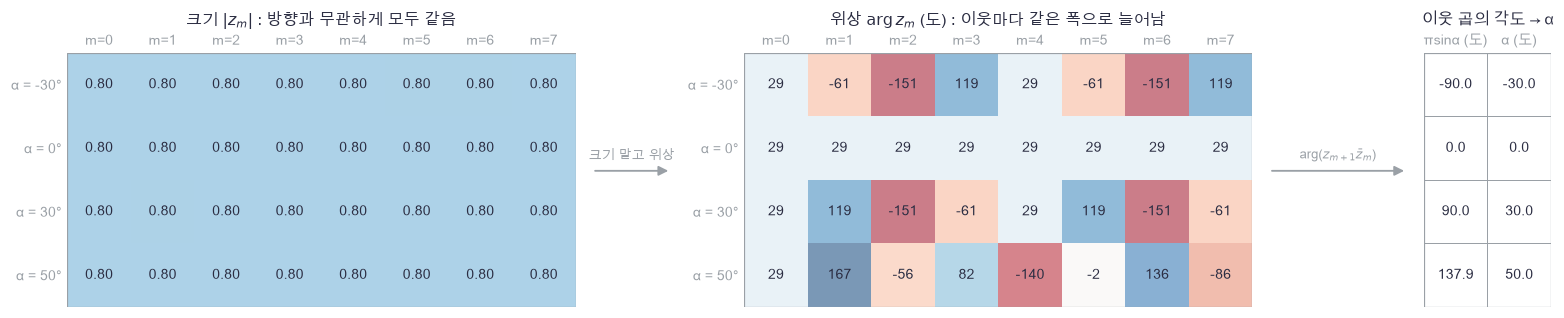

In [12]:
plot_magnitude_vs_phase(phase_alpha_deg, phase_magnitude, phase_deg, np.rad2deg(phase_step), phase_recovered)

In [13]:
# 쓰는 것: mnist_7, mnist_3 (📎 데이터 셀)
fourier_7 = np.fft.fft2(mnist_7)                                          # (28, 28) 복소 계수
fourier_3 = np.fft.fft2(mnist_3)
swap_7phase = np.fft.ifft2(np.abs(fourier_3) * np.exp(1j * np.angle(fourier_7))).real   # (28, 28): 7의 위상 + 3의 크기
swap_3phase = np.fft.ifft2(np.abs(fourier_7) * np.exp(1j * np.angle(fourier_3))).real   # (28, 28): 3의 위상 + 7의 크기
corr_7phase = [np.corrcoef(swap_7phase.ravel(), ref.ravel())[0, 1] for ref in (mnist_7, mnist_3)]   # [7과, 3과]
corr_3phase = [np.corrcoef(swap_3phase.ravel(), ref.ravel())[0, 1] for ref in (mnist_7, mnist_3)]
print("7의 위상 + 3의 크기 → 상관 [7과, 3과]:", np.round(corr_7phase, 3))
print("3의 위상 + 7의 크기 → 상관 [7과, 3과]:", np.round(corr_3phase, 3))
print("복원 값의 범위:", swap_7phase.min().round(3), "–", swap_7phase.max().round(3))

7의 위상 + 3의 크기 → 상관 [7과, 3과]: [0.775 0.276]
3의 위상 + 7의 크기 → 상관 [7과, 3과]: [0.045 0.775]
복원 값의 범위: -0.616 – 1.968


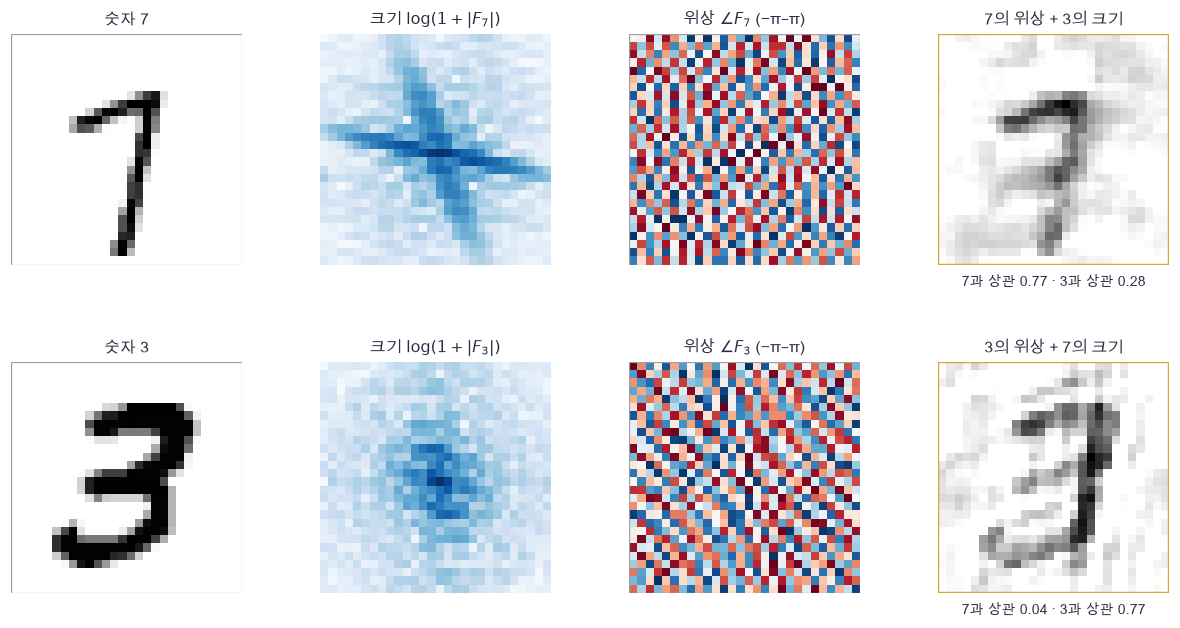

In [14]:
plot_phase_swap([mnist_7, mnist_3], [np.fft.fftshift(np.log1p(np.abs(F))) for F in (fourier_7, fourier_3)],
                [np.fft.fftshift(np.angle(F)) for F in (fourier_7, fourier_3)], [swap_7phase, swap_3phase], ["7", "3"],
                [corr_7phase, corr_3phase])

🔍 **확인** · 첫 그림의 크기 표는 네 방향·여덟 마이크 모두 0.8 한 가지 값입니다. 위상 표는 행마다 같은 폭으로 늘어나고(−180°–180° 밖으로 나가면 한 바퀴 접힘), 이웃 곱의 각도는 −90.0°, 0.0°, 90.0°, 137.9°이며 $\arcsin$으로 되찾은 방향은 −30.0°, 0.0°, 30.0°, 50.0°입니다.
둘째 그림의 크기 $\log(1+|F|)$는 두 숫자 모두 가운데(낮은 주파수)가 진하지만 모양은 다릅니다. 7은 두 획에 수직으로 뻗은 X자 줄무늬가 뚜렷하고, 3은 가운데에 퍼진 덩어리입니다. 위상은 두 숫자 모두 잡음처럼 보입니다. 그런데 교환 복원은 **위상을 준 숫자**를 닮습니다: "7의 위상 + 3의 크기"는 7과 상관 0.775, 3과 0.276이고, "3의 위상 + 7의 크기"는 7과 0.045, 3과 0.775입니다. 크기는 "어떤 굵기·방향의 무늬가 얼마나 있나"를, 위상은 "그 무늬들이 어디에 놓여 겹치나"를 담아서, 획이 어디에 그어지는지는 위상이 정하기 때문입니다.
아래 구현은 두 계산을 함수로 적고, 역변환·에너지 보존과 "전체 위상과 무관한 방향 읽기"를 확인합니다.

In [15]:
def neighbor_phase_direction(Z):
    """이웃 마이크 위상 차이로 방향을 읽습니다: α = arcsin(arg(Σ_m z_{m+1} z̄_m) / π).
    Z: (N, M) 복소, 행마다 신호 하나 → (N,) 라디안."""
    step = np.angle(np.sum(Z[:, 1:] * Z[:, :-1].conj(), axis=1))   # (N,): 이웃 곱 M−1개를 더한 뒤의 각도 = πsinα
    return np.arcsin(step / np.pi)


def swap_magnitude_phase(phase_image, magnitude_image):
    """phase_image의 푸리에 위상과 magnitude_image의 푸리에 크기로 되돌린 이미지. 둘 다 (H, W) 실수 → (H, W) 실수."""
    F_phase = np.fft.fft2(phase_image)
    F_magnitude = np.fft.fft2(magnitude_image)
    return np.fft.ifft2(np.abs(F_magnitude) * np.exp(1j * np.angle(F_phase))).real

In [16]:
# 쓰는 것: mnist_7, mnist_3 (📎 데이터 셀) · phase_z, phase_alpha_deg, phase_magnitude (2절 마이크 셀) · fourier_7, swap_7phase, swap_3phase (2절 MNIST 셀)
np.testing.assert_allclose(np.rad2deg(neighbor_phase_direction(phase_z)), phase_alpha_deg, atol=1e-9)   # 검산: 네 방향을 정확히 되찾음
rotated_z = phase_z * np.exp(1j * 2.0)                                     # 같은 소리의 전체 위상만 2 라디안 돌림
np.testing.assert_allclose(neighbor_phase_direction(rotated_z), neighbor_phase_direction(phase_z), atol=1e-12)   # 검산: s의 위상과 무관
np.testing.assert_allclose(np.abs(rotated_z), phase_magnitude)             # 검산: 크기도 그대로 (방향 정보 없음)
np.testing.assert_allclose(phase_magnitude, np.abs(phase_z[0, 0]))          # 검산: 크기는 방향·마이크와 무관하게 |s|
np.testing.assert_allclose(np.fft.ifft2(fourier_7).real, mnist_7, atol=1e-12)   # 검산: ifft2(fft2(x)) = x
np.testing.assert_allclose(np.sum(mnist_7 ** 2), np.sum(np.abs(fourier_7) ** 2) / mnist_7.size)   # 검산: Parseval
np.testing.assert_allclose(swap_magnitude_phase(mnist_7, mnist_3), swap_7phase)   # 검산: 위 그림의 7의 위상 + 3의 크기
np.testing.assert_allclose(swap_magnitude_phase(mnist_3, mnist_7), swap_3phase)   # 검산: 3의 위상 + 7의 크기
np.testing.assert_allclose(swap_magnitude_phase(mnist_7, mnist_7), mnist_7, atol=1e-12)   # 검산: 자기 위상 + 자기 크기 = 원본
print("방향 되찾기 · 전체 위상과 무관 · 역변환 · Parseval · 교환 복원 모두 통과")

방향 되찾기 · 전체 위상과 무관 · 역변환 · Parseval · 교환 복원 모두 통과


🔍 **확인** · 전체 위상을 2 라디안 돌린 같은 소리에서도 되찾은 방향이 같고 크기 표도 그대로입니다. 방향은 위상 **차이**에만 있고, 크기에는 없고, 전체 위상은 방향과 무관합니다. 5절의 세 모델은 이 세 사실을 각자 다르게 다룹니다. 이미지에서는 되돌린 값이 원본과 같고 에너지도 같아, 크기와 위상 두 배열이 이미지 정보를 빠짐없이 나눠 가집니다.

### ✏️ 연습 2 · 크기와 위상을 다른 배열에서 가져오기

같은 모양의 복소 배열 두 개에서 크기는 `F_magnitude`의 것을, 위상은 `F_phase`의 것을 가져온 복소 배열 `F_new`를 만드는 한 줄을 채우세요. 1절의 극형식 $re^{i\theta}$에서 $r$과 $\theta$를 서로 다른 곳에서 가져오는 것입니다.

In [17]:
def exercise_polar_recombine(F_phase, F_magnitude):
    """연습 2: 크기와 위상을 다른 배열에서 가져와 복소 배열 하나로. F_phase, F_magnitude: 같은 모양의 복소 배열 → |F_magnitude|·e^{i∠F_phase}."""
    assert F_phase.shape == F_magnitude.shape, "두 배열의 모양이 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 크기는 F_magnitude의 절댓값, 위상은 F_phase의 편각인 복소 배열 F_new (모양 그대로)
    ### 힌트: 2절 MNIST 셀의 ifft2 괄호 안쪽 식입니다. np.abs, np.angle, np.exp(1j * …)
    raise NotImplementedError
    return F_new

In [18]:
def check_polar_recombine(candidate):
    """(1, 2) 손계산과 2절의 7·3 푸리에 계수로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: fourier_7, fourier_3, swap_7phase (2절 MNIST 셀)
    example_phase = np.array([[2j, -3 + 0j]])                    # 위상 90°, 180°
    example_magnitude = np.array([[5 + 0j, 0.5j]])               # 크기 5, 0.5
    F_new = candidate(example_phase, example_magnitude)
    assert F_new.shape == (1, 2), f"모양은 (1, 2)여야 하는데 {np.shape(F_new)}입니다"
    np.testing.assert_allclose(F_new, [[5j, -0.5]], atol=1e-12)  # 검산: 5·e^{i90°} = 5i, 0.5·e^{i180°} = −0.5
    swapped = candidate(fourier_7, fourier_3)
    np.testing.assert_allclose(np.abs(swapped), np.abs(fourier_3))                # 검산: 크기는 3의 것
    np.testing.assert_allclose(np.fft.ifft2(swapped).real, swap_7phase, atol=1e-12)   # 검산: 되돌리면 2절의 "7의 위상 + 3의 크기"
    print("크기와 위상 나눠 가져오기: 손계산·2절 복원과 일치합니다.")

run_check(check_polar_recombine, exercise_polar_recombine, hint="F_new = np.abs(F_magnitude) * np.exp(1j * np.angle(F_phase))")

☐ exercise_polar_recombine: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: F_new = np.abs(F_magnitude) * np.exp(1j * np.angle(F_phase))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
F_new = np.abs(F_magnitude) * np.exp(1j * np.angle(F_phase))
```

</details>

## 🔑 3. 복소 파라미터의 기울기: 실수부와 허수부의 편미분을 묶습니다

**이 절에서 가져갈 것:** 실수 손실 $L$을 복소 파라미터 $z=x+iy$로 줄일 때 쓰는 기울기는 두 편미분을 복소수 하나로 묶은 $g_z=\dfrac{\partial L}{\partial x}+i\dfrac{\partial L}{\partial y}$이고, 갱신 `z -= lr * g`는 실수 좌표 $(x, y)$의 경사하강과 같습니다. 복소 선형층 $Z=XW+b$의 backward는 전치 대신 **켤레전치**를 씁니다: `gW = X.conj().T @ gZ`, `gX = gZ @ W.conj().T`, `gb = gZ.sum(axis=0)`.

📎 데이터 셀의 마이크 1번 신호 $z_1$을 기준 화살표 $c=1$(길이 1, 각도 0)에 맞추고 싶다고 합시다. 곱할 복소 가중치 $w$ 하나를 찾는 문제이고, 손실은 $L(w)=|wz_1-c|^2$입니다. $w$는 평면의 점 $(\mathrm{Re}\,w, \mathrm{Im}\,w)$이므로 01번 6절의 경사하강을 두 좌표에 그대로 쓰면 됩니다. 두 좌표의 기울기를 복소수 하나로 묶어 두면, 식을 복소수 곱셈으로 짧게 쓸 수 있습니다.

> **용어**
>
> - **Wirtinger 미분**: $\dfrac{\partial}{\partial z}=\dfrac12\Big(\dfrac{\partial}{\partial x}-i\dfrac{\partial}{\partial y}\Big)$, $\dfrac{\partial}{\partial\bar z}=\dfrac12\Big(\dfrac{\partial}{\partial x}+i\dfrac{\partial}{\partial y}\Big)$. $z$와 $\bar z$를 서로 다른 변수처럼 보고 미분하는 규칙입니다. 예: $\partial(z\bar z)/\partial\bar z=z$. 정의에서 바로 $g_z=2\,\partial L/\partial\bar z$입니다.
> - **켤레전치(conjugate transpose, Hermitian transpose)** $X^H=\overline{X}^\top$: 전치하고 모든 원소의 켤레를 취한 것. 코드에서는 `X.conj().T`. 실수 행렬이면 그냥 전치입니다.

**손계산.** $L=|z-c|^2=(x-c_x)^2+(y-c_y)^2$이면 $\partial L/\partial x=2(x-c_x)$, $\partial L/\partial y=2(y-c_y)$이므로

$$g_z=2(z-c).$$

Wirtinger로는 $L=(z-c)(\bar z-\bar c)$에서 $\partial L/\partial\bar z=z-c$라 $g_z=2\,\partial L/\partial\bar z$로 같습니다. 반대로 $2\,\partial L/\partial z=2(\bar z-\bar c)=\overline{g_z}$는 허수부의 부호가 반대라서, 이것으로 갱신하면 허수부가 오르막으로 갑니다.

**연쇄 법칙.** $w=f(z)$를 거쳐 실수 손실 $L$에 닿고 $w$의 기울기가 $g_w$이면

$$g_z=\overline{g_w}\,\frac{\partial f}{\partial\bar z}+g_w\,\overline{\frac{\partial f}{\partial z}}.$$

$z$에서 $w$로 가는 두 길($\partial f/\partial z$, $\partial f/\partial\bar z$)의 기여를 더한 것입니다. $f$에 $\bar z$가 들어 있지 않으면 $\partial f/\partial\bar z=0$이라 $g_z=g_w\,\overline{f'(z)}$만 남습니다. 실수 파라미터 $\beta$가 복소 출력 $w$를 거치면 $\partial L/\partial\beta=\sum\mathrm{Re}\big(g_w\,\overline{\partial w/\partial\beta}\big)$입니다(4절에서 씀).

위의 맞추기 문제에 쓰면, 여기서는 가중치가 $w$이므로 공식의 입력 $z$ 자리에 $w$를, 출력 자리에 중간값 $u=wz_1-c$를 놓습니다. 손실은 $L=|u|^2$이라 손계산대로 $g_u=2u$이고, $u$에는 $\bar w$가 없으며 $\partial u/\partial w=z_1$이므로

$$g_w=g_u\,\overline{z_1}=2(wz_1-c)\,\bar z_1$$

이고, 최솟값은 $u=0$인 $w^*=c/z_1$입니다.

**선형층.** $Z_{nk}=\sum_dX_{nd}W_{dk}+b_k$에서 $\partial Z_{nk}/\partial W_{dk}=X_{nd}$이므로 $g_{W_{dk}}=\sum_ng_{Z,nk}\overline{X_{nd}}$이고, 행렬로 모으면

$$g_W=X^Hg_Z,\qquad g_b=\sum_ng_{Z,n},\qquad g_X=g_Z\,\overline{W}^\top.$$

$g_W$의 $(d, k)$ 칸은 입력 $d$열의 켤레와 출력 $k$열 기울기의 내적입니다. 03번 5절의 `dW = A_prev.T @ dZ`, `dA_prev = dZ @ W.T`(여기서는 층의 입력 `A_prev`가 `X`)에서 전치가 켤레전치로 바뀐 것뿐이고, 실수 입력이면 두 식은 같습니다.

> **코드**
>
> - `X.conj().T @ gZ`: $X^Hg_Z$. **`@`는 켤레를 취하지 않습니다.** `X.T @ gZ`라고 쓰면 오류 없이 다른 값이 나오므로 검산으로만 잡을 수 있습니다.
> - `np.vdot(a, b)`: $\sum_i\overline{a_i}\,b_i$. `@`와 달리 **첫 인자에 켤레**를 취합니다. `np.vdot(z, z)`는 $\sum|z_i|^2$(허수부가 0인 복소수)입니다.
> - `for _ in range(12):`: 반복 번호를 쓰지 않는 반복문. `_`는 "쓰지 않는 변수"라는 관례 이름입니다.
> - `for unit in (1, 1j):`: 실수 방향($\pm\epsilon$)과 허수 방향($\pm i\epsilon$)으로 한 번씩 흔들어 $\partial L/\partial x$, $\partial L/\partial y$를 따로 잽니다. `unit * (차분)`으로 더하면 둘째 것에 $i$가 붙어 $g$가 됩니다.
> - `np.meshgrid(xs, ys)`: 가로 좌표 `xs`와 세로 좌표 `ys`의 모든 쌍을 두 배열 `(len(ys), len(xs))`로. 격자 전체의 $w$를 `re + 1j * im` 한 번에 만들어 손실 지형을 칸마다 계산합니다.
> - `np.ndindex(*z.shape)`: 배열의 모든 자리 `(i, j, …)`를 차례로 돕니다. 01번 3절 중심차분의 반복문과 같은 역할입니다.
> - `{name: f"{error:.1e}" for name, error in grad_errors.items()}`: 사전 컴프리헨션. `.items()`가 `(키, 값)` 쌍을 차례로 주면 두 이름에 나눠 받아, 같은 키에 출력용 문자열을 단 새 사전을 만듭니다.

In [19]:
hand_c = 0.5 - 0.5j                                                 # 목표 c
hand_point = 2 + 1j                                                 # 기울기를 잴 점 z
eps = 1e-6
hand_loss = np.abs(hand_point - hand_c) ** 2                        # L = |z − c|² = 1.5² + 1.5²
dL_dx = (np.abs(hand_point + eps - hand_c) ** 2 - np.abs(hand_point - eps - hand_c) ** 2) / (2 * eps)            # 실수 방향 중심차분
dL_dy = (np.abs(hand_point + 1j * eps - hand_c) ** 2 - np.abs(hand_point - 1j * eps - hand_c) ** 2) / (2 * eps)  # 허수 방향 중심차분
hand_g = dL_dx + 1j * dL_dy                                         # g = ∂L/∂x + i ∂L/∂y
print(f"L = {hand_loss:.2f} · ∂L/∂x = {dL_dx:.4f}, ∂L/∂y = {dL_dy:.4f} → g = {hand_g:.4f}")
print(f"손계산 2(z − c) = {2 * (hand_point - hand_c):.4f} · 켤레 쪽 2∂L/∂z = 2(z̄ − c̄) = {2 * np.conj(hand_point - hand_c):.4f}")

L = 4.50 · ∂L/∂x = 3.0000, ∂L/∂y = 3.0000 → g = 3.0000+3.0000j
손계산 2(z − c) = 3.0000+3.0000j · 켤레 쪽 2∂L/∂z = 2(z̄ − c̄) = 3.0000-3.0000j


In [20]:
# 쓰는 것: mic_z (📎 데이터 셀)
align_z, align_c, align_lr = mic_z[1], 1.0, 0.3                     # 마이크 1번 신호, 기준 화살표, 학습률
align_star = align_c / align_z                                      # 최솟값 w* = c / z₁
align_good = [1.0 + 0j]                                             # w₀ = 1 (돌리지 않음)에서 시작
for _ in range(12):
    w = align_good[-1]
    align_good.append(w - align_lr * 2 * (w * align_z - align_c) * np.conj(align_z))   # g = 2(wz₁ − c) z̄₁
align_wrong = [1.0 + 0j]
for _ in range(4):
    w = align_wrong[-1]
    align_wrong.append(w - align_lr * np.conj(2 * (w * align_z - align_c) * np.conj(align_z)))   # 켤레를 잘못 둔 2∂L/∂w = ḡ
align_good, align_wrong = np.array(align_good), np.array(align_wrong)
grid_re, grid_im = np.meshgrid(np.linspace(-3.25, 3.25, 131), np.linspace(-3.25, 3.25, 131))   # (131, 131) 두 개: 빨간 경로 4스텝이 모두 들어가는 범위
grid_loss = np.abs((grid_re + 1j * grid_im) * align_z - align_c) ** 2                          # (131, 131): 손실 지형
arrow_w = (np.linspace(-3, 3, 9)[None, :] + 1j * np.linspace(-3, 3, 9)[:, None]).ravel()      # (81,): 화살표를 그릴 점
arrow_g = 2 * (arrow_w * align_z - align_c) * np.conj(align_z)                                # (81,): 점마다 g
print("w* =", np.round(align_star, 4), "· 12스텝 뒤 w =", np.round(align_good[-1], 4), "· |w z₁ − c| =", np.abs(align_good[-1] * align_z - align_c).round(4))
print("잘못된 방향 4스텝의 |w − w*|:", np.abs(align_wrong - align_star).round(3))

w* = (-0.5993-1.097j) · 12스텝 뒤 w = (-0.5945-1.0937j) · |w z₁ − c| = 0.0046
잘못된 방향 4스텝의 |w − w*|: [1.939 1.81  2.187 2.932 4.031]


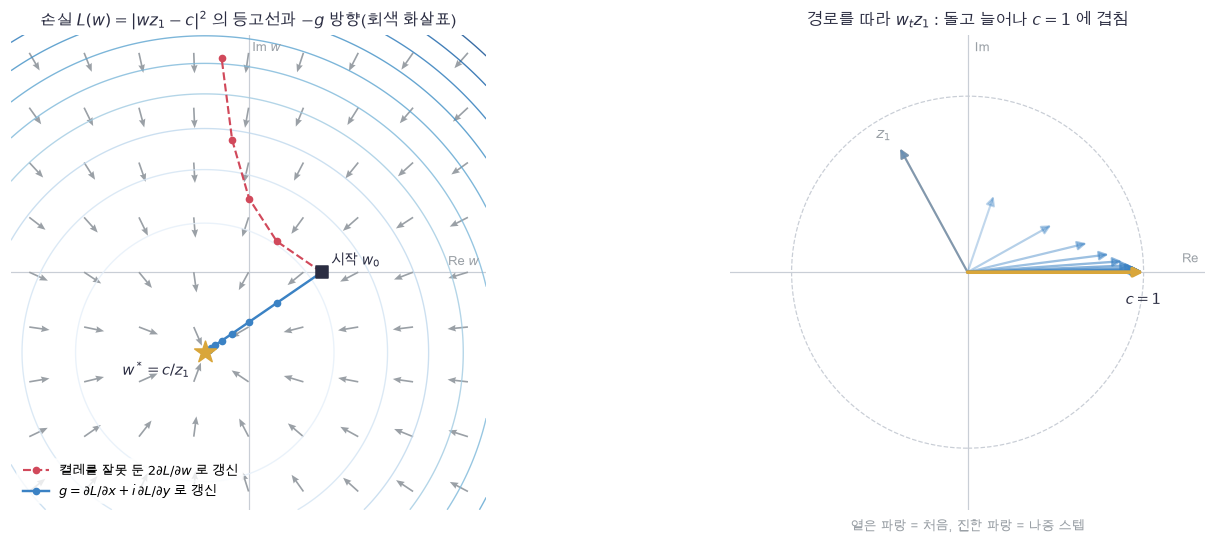

In [21]:
plot_complex_descent(grid_re, grid_im, grid_loss, arrow_w, arrow_g, align_good, align_wrong, align_star, align_z, align_c)

🔍 **확인** · 손계산 점 $z=2+i$, $c=0.5-0.5i$에서 실수·허수 방향 중심차분이 각각 3.0000이라 $g=3+3i=2(z-c)$입니다. 켤레 쪽 $2(\bar z-\bar c)=3-3i$는 허수부 부호가 반대입니다.
그림의 회색 화살표 $-g$는 등고선에 수직으로 금색 별 $w^*=c/z_1$을 향하고, 파란 경로는 그 방향으로 곧게 내려가 12스텝 뒤 $|wz_1-c|$가 0.0046입니다. 빨간 경로($\overline{g}$로 갱신)는 실수부는 맞게 움직이지만 허수부가 반대로 가서, $|w-w^*|$가 4스텝 동안 1.939에서 4.031로 커집니다. 오른쪽에서 $w_tz_1$ 화살표는 돌고 늘어나 $c=1$에 겹칩니다. 가중치의 위상이 신호의 위상 $-\arg z_1$을 상쇄하고, 크기가 $1/|z_1|$을 맞춘 것입니다.
아래 구현은 복소 배열의 중심차분과 복소 선형층 backward이고, 켤레를 빼먹은 오답이 검산에서 잡히는지도 봅니다.

In [22]:
def complex_numerical_gradient(f, z, eps=1e-6):
    """복소 배열 z의 기울기 g = ∂L/∂x + i ∂L/∂y 를 중심차분으로 잽니다 (01번 3절을 실수부·허수부에 한 번씩).
    f: 인자 없이 z를 들여다보는 실수 스칼라 함수, z: 제자리에서 흔들고 되돌리는 복소 배열 → z와 같은 모양의 복소 배열."""
    g = np.zeros(z.shape, dtype=complex)
    for idx in np.ndindex(*z.shape):
        original = z[idx]
        for unit in (1, 1j):                                # 실수 방향 → ∂L/∂x, 허수 방향 → ∂L/∂y
            z[idx] = original + eps * unit
            f_plus = f()
            z[idx] = original - eps * unit
            f_minus = f()
            g[idx] += unit * (f_plus - f_minus) / (2 * eps)   # unit = 1j면 i·∂L/∂y로 더해짐
        z[idx] = original                                   # 원상복구
    return g


def complex_rel_error(a, b):
    """두 복소 기울기의 상대오차: 실수부·허수부를 두 실수 배열로 쌓아 rel_error(max |차이| / max |값|)에 넘깁니다."""
    return rel_error(np.stack([a.real, a.imag]), np.stack([b.real, b.imag]))

In [23]:
def complex_linear_backward(gZ, X, W):
    """복소 선형층 Z = XW + b 의 backward. g = ∂L/∂Re + i ∂L/∂Im 관례.
    gZ: (N, K), X: (N, D), W: (D, K) 복소 → (gX: (N, D), gW: (D, K), gb: (K,))."""
    gW = X.conj().T @ gZ                                    # (D, K): g_W = Xᴴ g_Z
    gb = gZ.sum(axis=0)                                     # (K,): 모든 표본에 더해졌으니 표본 축의 합
    gX = gZ @ W.conj().T                                    # (N, D): g_X = g_Z W̄ᵀ
    return gX, gW, gb

In [24]:
# 쓰는 것: complex_linear (1절)
grad_rng = np.random.default_rng(12)
grad_X = grad_rng.normal(size=(5, 4)) + 1j * grad_rng.normal(size=(5, 4))   # (N=5, D=4)
grad_W = grad_rng.normal(size=(4, 3)) + 1j * grad_rng.normal(size=(4, 3))   # (D=4, K=3)
grad_b = grad_rng.normal(size=3) + 1j * grad_rng.normal(size=3)             # (K=3,)
grad_T = grad_rng.normal(size=(5, 3)) + 1j * grad_rng.normal(size=(5, 3))   # (N, K): 목표


def squared_error():
    """검사기용: L = Σ |XW + b − T|² (실수 스칼라)."""
    return float(np.sum(np.abs(complex_linear(grad_X, grad_W, grad_b) - grad_T) ** 2))


grad_gZ = 2 * (complex_linear(grad_X, grad_W, grad_b) - grad_T)             # (N, K): 손계산의 g = 2(z − c)를 원소마다
grad_gX, grad_gW, grad_gb = complex_linear_backward(grad_gZ, grad_X, grad_W)
grad_errors = {"X": complex_rel_error(grad_gX, complex_numerical_gradient(squared_error, grad_X)),
               "W": complex_rel_error(grad_gW, complex_numerical_gradient(squared_error, grad_W)),
               "b": complex_rel_error(grad_gb, complex_numerical_gradient(squared_error, grad_b))}
print("복소 선형층의 상대오차:", {name: f"{error:.1e}" for name, error in grad_errors.items()})
assert max(grad_errors.values()) < 1e-6, "X, W, b 기울기의 상대오차가 모두 1e−6 아래여야 합니다"

복소 선형층의 상대오차: {'X': '8.7e-10', 'W': '7.5e-10', 'b': '1.0e-09'}


In [25]:
# 쓰는 것: grad_X, grad_gZ, grad_gW, squared_error (3절 검산 셀) · hand_point, hand_c, hand_g (3절 손계산 셀) · align_good, align_z, align_c (3절 정렬 셀)
wrong_gW = grad_X.T @ grad_gZ                                               # 오답: 켤레를 빼먹은 전치
wrong_error = complex_rel_error(wrong_gW, complex_numerical_gradient(squared_error, grad_W))
print(f"켤레를 빼먹은 X.T @ gZ 의 상대오차: {wrong_error:.3f}")
assert wrong_error > 0.1, "켤레를 빼먹은 기울기는 검산에서 크게 틀려야 합니다"
hand_array = np.array([hand_point])                                          # (1,): 손계산 점을 배열로


def hand_loss_fn():
    """검사기용: L = |z − c|² (손계산 점)."""
    return float(np.abs(hand_array[0] - hand_c) ** 2)


np.testing.assert_allclose(complex_numerical_gradient(hand_loss_fn, hand_array), [2 * (hand_point - hand_c)], atol=1e-8)   # 검산: g = 2(z − c)
np.testing.assert_allclose(hand_g, 2 * (hand_point - hand_c), atol=1e-8)     # 검산: 손계산 셀의 중심차분과 같음
np.testing.assert_allclose(np.vdot(grad_X[:, 0], grad_gZ[:, 0]), grad_gW[0, 0])   # 검산: gW의 한 칸 = 입력 열의 켤레와 기울기 열의 내적
assert abs(align_good[-1] * align_z - align_c) < 1e-2, "12스텝 뒤 w z₁이 c에 0.01 안으로 가까워야 합니다"
print("손계산 g = 2(z − c), np.vdot으로 본 gW의 한 칸, 위상 맞추기 수렴 모두 통과")

켤레를 빼먹은 X.T @ gZ 의 상대오차: 1.550
손계산 g = 2(z − c), np.vdot으로 본 gW의 한 칸, 위상 맞추기 수렴 모두 통과


🔍 **확인** · 복소 선형층의 $X$, $W$, $b$ 기울기가 실수부·허수부 중심차분과 상대오차 $10^{-9}$ 수준에서 같습니다. `X.T @ gZ`처럼 켤레를 빼먹으면 모양도 같고 오류도 나지 않지만 상대오차가 1.550이라 검산이 잡습니다. `np.vdot`으로 쓴 $g_W$의 한 칸은 "입력 열의 켤레와 기울기 열의 내적"이라는 식 그대로입니다.

📎 **참고** · PyTorch도 같은 관례입니다. 이 저장소 `.venv`의 PyTorch 2.14로 복소 텐서 $z$에 실수 손실 `((z - c).abs() ** 2).sum()`을 두고 `backward()`하면 `z.grad`가 $2(z-c)$이고, 선형층 가중치의 `grad`는 `X.conj().T @ gZ`와 같았습니다(제작 때 확인, 이 노트북에서는 PyTorch를 부르지 않습니다). 다른 도구를 쓸 때도 이 절의 손계산 $L=|z-c|^2$ 하나로 어느 관례인지 먼저 확인하세요.

### ✏️ 연습 3 · 켤레전치로 돌아가는 기울기

복소 선형층 $Z=XW+b$에서 출력 기울기 `gZ` `(N, K)`가 주어졌을 때 가중치 기울기 `gW` `(D, K)`와 입력 기울기 `gX` `(N, D)` 두 줄을 채우세요. 03번의 실수 식에서 전치 자리를 켤레전치로 바꿉니다. 켤레를 빼먹으면 모양은 맞아도 값이 달라 검사가 잡습니다.

In [26]:
def exercise_complex_linear_backward(gZ, X, W):
    """연습 3: 복소 선형층의 입력·가중치 기울기. gZ: (N, K), X: (N, D), W: (D, K) 복소 → (gX: (N, D), gW: (D, K))."""
    assert X.shape[1] == W.shape[0], "X의 열 수 D와 W의 행 수 D가 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: gW = Xᴴ g_Z (모양 (D, K))와 gX = g_Z W̄ᵀ (모양 (N, D))
    ### 힌트: 03번 5절의 dW = A_prev.T @ dZ, dA_prev = dZ @ W.T(여기서 A_prev가 X)에서 .T 앞에 .conj()를 붙입니다. @는 켤레를 취하지 않습니다
    raise NotImplementedError
    return gX, gW

In [27]:
def check_complex_linear_backward(candidate):
    """(1, 1) 손계산과 3절 검산 셀의 배열(complex_linear_backward)로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: complex_linear_backward (3절) · grad_X, grad_W, grad_gZ (3절 검산 셀)
    gX, gW = candidate(np.array([[1.0 + 0j]]), np.array([[1j]]), np.array([[1 + 1j]]))   # gZ = 1, X = i, W = 1 + i
    np.testing.assert_allclose(gW, [[-1j]])                 # 검산: conj(i)·1 = −i (켤레를 빼먹으면 +i)
    np.testing.assert_allclose(gX, [[1 - 1j]])              # 검산: 1·conj(1 + i) = 1 − i
    gX, gW = candidate(grad_gZ, grad_X, grad_W)
    assert gW.shape == (4, 3), f"gW는 (D, K) = (4, 3)이어야 하는데 {np.shape(gW)}입니다"
    reference_gX, reference_gW, _ = complex_linear_backward(grad_gZ, grad_X, grad_W)
    np.testing.assert_allclose(gW, reference_gW)            # 검산: 3절 complex_linear_backward의 gW
    np.testing.assert_allclose(gX, reference_gX)            # 검산: gX도 같음
    print("켤레전치로 돌아가는 기울기: 손계산·complex_linear_backward와 일치합니다.")

run_check(check_complex_linear_backward, exercise_complex_linear_backward, hint="gW = X.conj().T @ gZ, gX = gZ @ W.conj().T")

☐ exercise_complex_linear_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: gW = X.conj().T @ gZ, gX = gZ @ W.conj().T


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
gW = X.conj().T @ gZ
gX = gZ @ W.conj().T
```

</details>

## 🔑 4. 활성화: 복소수의 tanh는 발산하므로 크기와 위상을 나눠 다룹니다

**이 절에서 가져갈 것:** 복소평면 전체에서 미분 가능하고(정칙) 값이 유계인 함수는 상수뿐이라(Liouville 정리), 실수에서 쓰던 $\tanh$를 복소수에 그대로 쓰면 극 $z=\pm i\pi/2$에서 발산합니다. 그래서 정칙을 포기하고 크기와 위상을 나눠 다루는 **modReLU** $f(z)=\mathrm{ReLU}(|z|+b)\,\dfrac{z}{|z|}$를 씁니다. 곱하는 배율 $\mathrm{ReLU}(|z|+b)/|z|$가 $|z|$에만 달려 있어 크기만 바꾸고($b<0$이면 줄이고) 방향은 그대로 두며, $|e^{i\varphi}z|=|z|$라 돌린 입력에도 같은 배율이 곱해지므로 $f(e^{i\varphi}z)=e^{i\varphi}f(z)$(위상 등변)입니다. 실수부·허수부에 따로 ReLU를 거는 CReLU는 등변이 아닙니다.

마이크 신호를 한 층 지난 값에 활성화를 건다고 합시다. "소리가 약하면 끄고 강하면 통과"시키고 싶습니다. 그런데 전선이 조금 길어져 모든 신호가 같은 각도만큼 돌았다고(1절) 끄고 켜는 판단이 달라지면 곤란합니다. 판단은 크기로만 하고, 통과한 신호의 위상은 건드리지 않는 것이 modReLU입니다.

> **용어**
>
> - **정칙(holomorphic)**: 복소평면의 한 영역에서 $z$로 미분 가능한 함수. $\bar z$ 없이 $z$만으로 쓰는 식($z^2$, $e^z$, $\tanh z$)이고 $\partial f/\partial\bar z=0$입니다. $|z|$, $\bar z$, $\mathrm{Re}\,z$는 정칙이 아닙니다.
> - **극(pole)**: 함수값이 한없이 커지는 점. $\tanh z=\sinh z/\cosh z$는 $\cosh z=0$인 $z=i\pi/2+ik\pi$($k$는 정수)에서 극을 가집니다.
> - **Liouville 정리**: 복소평면 전체에서 정칙이고 크기가 어떤 상수 이하로 묶인(유계인) 함수는 상수 함수뿐이라는 복소해석학의 정리. 증명은 복소해석학 교재에 있고, 여기서는 결론만 씁니다.
> - **modReLU**(Arjovsky 등, 2016): 크기 $|z|$에 실수 편향 $b$를 더해 ReLU를 걸고, 방향 $z/|z|$를 곱해 되돌리는 활성화. $b<0$이면 $|z|<-b$인 짧은 화살표를 0으로 끕니다. 뉴런마다 $b$ 하나입니다.
> - **split 활성화·CReLU**: 실수부와 허수부에 실수 활성화를 따로 거는 것. $\mathrm{CReLU}(z)=\mathrm{ReLU}(\mathrm{Re}\,z)+i\,\mathrm{ReLU}(\mathrm{Im}\,z)$.
> - **위상 등변(phase equivariance)·위상 불변(phase invariance)**: 입력을 $e^{i\varphi}$만큼 돌리면 출력도 같은 각도만큼 돌면 등변, 출력이 그대로면 불변. 10번 5절의 "노드 번호 바꾸기", 05b번 4절의 "옆으로 옮기기"가 여기서는 "전체 위상 돌리기"입니다.

**왜 $\tanh$를 그대로 못 쓰나.** 실수 $\tanh$는 $(-1,1)$ 안에 머무는 유계 함수였습니다. 복소수로 넓히면 $\tanh(iy)=i\tan y$라서 $y\to\pi/2$에서 발산합니다. 이것은 $\tanh$만의 사정이 아니라 Liouville 정리 때문입니다. 값이 묶여 포화하는 활성화는 복소평면 전체에서 정칙일 수 없으므로, 실수에서 유계였던 $\tanh$·sigmoid도 복소수로 넓히면 어딘가에서 한없이 커지고, 이 둘은 원점에서 멀지 않은 유한한 점, 곧 극($\tanh$는 $\pm i\pi/2$, sigmoid는 $\pm i\pi$)에서 그렇게 됩니다. 그래서 복소 활성화는 정칙인 함수를 극에서 먼 곳에서만 쓰거나, 정칙을 포기해야 합니다. modReLU·CReLU는 정칙을 포기한 쪽입니다. 둘 다 실수 ReLU처럼 유계는 아니지만($|z|$가 커지면 출력도 커짐) 극이 없어 모든 $z$에서 유한하고, modReLU는 켜고 끄는 판단을 $|z|$만으로 해서 위상을 보존합니다(아래 등변). 정칙이 아니어도 3절의 연쇄 법칙은 $\partial f/\partial z$와 $\partial f/\partial\bar z$ 두 항으로 그대로 씁니다.

**modReLU의 도함수.** 켜진 곳($|z|+b>0$)에서 $f(z)=z+b\,z/|z|$이고, $|z|=(z\bar z)^{1/2}$를 Wirtinger로 미분하면

$$\frac{\partial f}{\partial z}=1+\frac{b}{2|z|},\qquad \frac{\partial f}{\partial\bar z}=-\frac{b\,z^2}{2|z|^3},\qquad \frac{\partial f}{\partial b}=\frac{z}{|z|}.$$

꺼진 곳은 셋 다 0입니다. $b\,z/|z|$ 항에 $\bar z$가 들어 있어 $\partial f/\partial\bar z\neq0$, 곧 정칙이 아닙니다. 3절의 연쇄 법칙에 넣으면

$$g_z=\overline{g_w}\Big(-\frac{b\,z^2}{2|z|^3}\Big)+g_w\Big(1+\frac{b}{2|z|}\Big),\qquad \frac{\partial L}{\partial b}=\sum_n\mathrm{Re}\Big(g_w\,\overline{z/|z|}\Big).$$

둘 다 켜진 자리에서만 더하고, $b$의 기울기는 뉴런마다 표본 축으로 더합니다(3절의 "실수 파라미터가 복소 출력을 거치면").

**등변.** $|e^{i\varphi}z|=|z|$이므로 $f(e^{i\varphi}z)=\mathrm{ReLU}(|z|+b)\,e^{i\varphi}z/|z|=e^{i\varphi}f(z)$입니다. 편향 없는 복소 선형층도 $(e^{i\varphi}X)W=e^{i\varphi}(XW)$로 등변입니다(1절 끝). 그래서 편향 없는 층과 modReLU를 몇 번 쌓아도 출력은 같은 각도만큼 돌 뿐이고, 마지막에 $|\cdot|^2$로 읽으면 $|e^{i\varphi}Y|^2=|Y|^2$라 **불변**입니다(5절). 복소 편향 $c$를 더하면 $e^{i\varphi}XW+c\neq e^{i\varphi}(XW+c)$라 이 성질이 깨집니다.

아래는 복소평면의 $|\tanh z|$와, 평면의 격자점 48개에 modReLU($b=-0.5$)와 CReLU를 적용한 화살표, 그리고 입력을 $0°$부터 $360°$까지 돌리며 잰 "등변에서 벗어난 정도"입니다.

> **코드**
>
> - `np.repeat([0.3, 0.7, 1.1, 1.5], 12)`, `np.tile(angles, 4)`: 반지름 네 개는 같은 값을 12번씩 잇고(`(48,)`), 각도 12개는 목록 통째로 4번 잇습니다(`(48,)`). 둘을 짝지으면 반지름 4개 × 각도 12개 = 점 48개입니다.
> - `np.maximum(r + b, 0) / (r + eps)`: $\mathrm{ReLU}(|z|+b)/|z|$. `eps`(1e−9)는 $|z|=0$에서 0으로 나누는 것을 막습니다. $b<0$이면 켜진 곳은 $|z|>-b>0$이라 실제로는 쓰이지 않고, $b\geq0$이면서 $z=0$일 때만 출력을 0으로 둡니다.
> - `np.real(np.vdot(G, out))`: $\sum\mathrm{Re}(\overline{G}\,w)$. 상류 기울기가 정확히 $G$가 되도록 만든 검사용 실수 손실입니다($\partial/\partial\,\mathrm{Re}\,w=\mathrm{Re}\,G$, $\partial/\partial\,\mathrm{Im}\,w=\mathrm{Im}\,G$).

In [28]:
tanh_re, tanh_im = np.meshgrid(np.linspace(-2.5, 2.5, 201), np.linspace(-3, 3, 241))   # (241, 201) 두 개: 복소평면 격자
tanh_abs = np.abs(np.tanh(tanh_re + 1j * tanh_im))                  # (241, 201): |tanh z|
tanh_line = np.linspace(-3, 3, 1201)                                # (1201,): 축 위의 좌표
tanh_real_axis = np.abs(np.tanh(tanh_line))                         # 실수축: |tanh x| < 1
tanh_imag_axis = np.abs(np.tanh(1j * tanh_line))                    # 허수축: |tanh iy| = |tan y|
print("실수축 |tanh x|의 최댓값:", tanh_real_axis.max().round(4))
print("허수축 y = 1.5, 1.57, 1.5707에서 |tanh iy|:", np.abs(np.tanh(1j * np.array([1.5, 1.57, 1.5707]))).round(1))

실수축 |tanh x|의 최댓값: 0.9951
허수축 y = 1.5, 1.57, 1.5707에서 |tanh iy|: [   14.1  1255.8 10381.3]


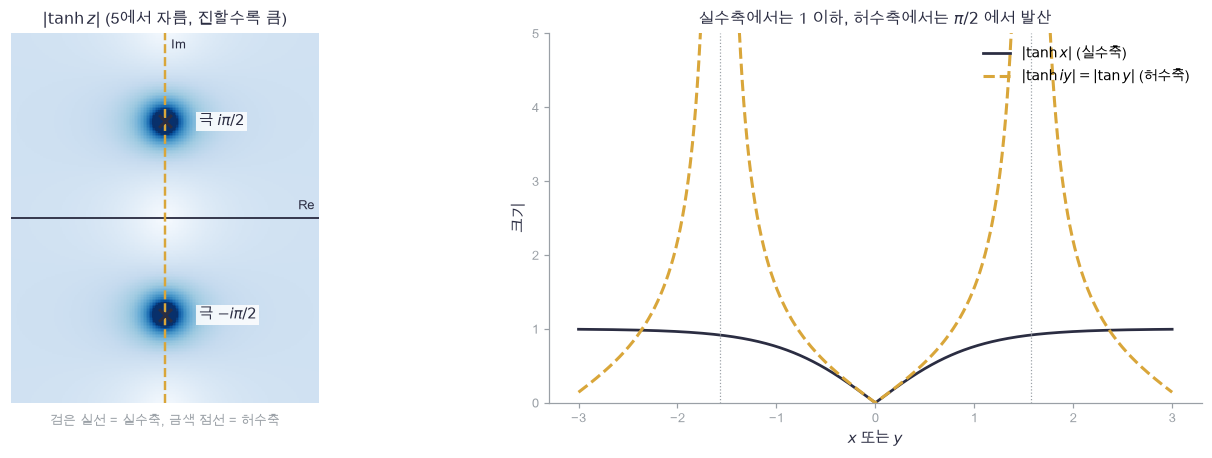

In [29]:
plot_tanh_blowup(tanh_re, tanh_im, tanh_abs, tanh_line, tanh_real_axis, tanh_imag_axis)

In [30]:
field_r = np.repeat([0.3, 0.7, 1.1, 1.5], 12)                       # (48,): 반지름 네 개를 12번씩
field_theta = np.tile(np.arange(12) * np.pi / 6 + np.pi / 12, 4)    # (48,): 15°부터 30°씩 12방향을 4번
field_z = field_r * np.exp(1j * field_theta)                        # (48,) 복소: 격자점
field_b = -0.5
field_mod = np.maximum(np.abs(field_z) + field_b, 0) * field_z / np.abs(field_z)   # (48,): modReLU
field_crelu = np.maximum(field_z.real, 0) + 1j * np.maximum(field_z.imag, 0)      # (48,): CReLU
field_turn = np.linspace(0, 2 * np.pi, 73)                          # (73,): 돌리는 각도 φ (5°씩)
field_rot = np.exp(1j * field_turn)[:, None] * field_z[None, :]     # (73, 48): 돌린 입력 e^{iφ} z
rot_mod = np.maximum(np.abs(field_rot) + field_b, 0) * field_rot / np.abs(field_rot)   # (73, 48): f(e^{iφ} z)
rot_crelu = np.maximum(field_rot.real, 0) + 1j * np.maximum(field_rot.imag, 0)
gap_mod = np.abs(rot_mod - np.exp(1j * field_turn)[:, None] * field_mod).max(axis=1)      # (73,): max |f(e^{iφ}z) − e^{iφ}f(z)|
gap_crelu = np.abs(rot_crelu - np.exp(1j * field_turn)[:, None] * field_crelu).max(axis=1)
print("0으로 꺼진 점:", int(np.sum(field_mod == 0)), "/ 48 · 켜진 점의 길이 변화:", np.unique((np.abs(field_mod) - field_r)[field_mod != 0].round(12)))
print(f"등변에서 벗어난 정도의 최댓값 · modReLU {gap_mod.max():.1e} · CReLU {gap_crelu.max():.3f}")

0으로 꺼진 점: 12 / 48 · 켜진 점의 길이 변화: [-0.5]
등변에서 벗어난 정도의 최댓값 · modReLU 4.0e-16 · CReLU 1.500


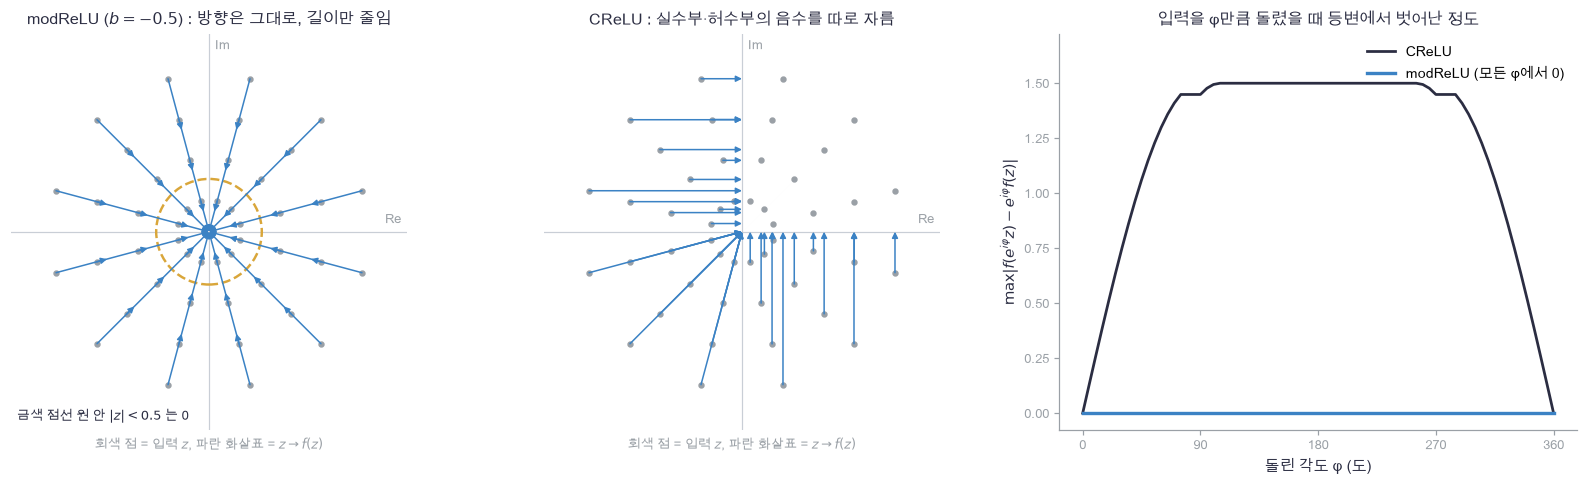

In [31]:
plot_activation_fields(field_z, field_mod, field_crelu, field_b, np.rad2deg(field_turn), gap_mod, gap_crelu)

🔍 **확인** · 첫 그림에서 검은 실선 실수축 위의 $|\tanh x|$는 최댓값 0.9951로 1을 넘지 않지만, 금색 점선 허수축 위에서는 $y=1.5, 1.57, 1.5707$에서 14.1, 1255.8, 10381.3으로, $\pi/2\approx1.5708$에 다가갈수록 치솟습니다. 평면 위의 진한 두 점이 극 $\pm i\pi/2$입니다.
둘째 그림 왼쪽의 modReLU 화살표는 모두 원점을 향해(방향 그대로) 0.5만큼 짧아지고, 금색 원 $|z|<0.5$ 안의 점 12개는 0으로 갑니다. 가운데 CReLU 화살표는 실수부나 허수부가 음수인 점에서 축 쪽으로 꺾이고, 셋째 사분면의 점은 모두 0이 됩니다. 오른쪽 곡선에서 modReLU는 모든 각도에서 등변 차이가 최대 $4\times10^{-16}$(부동소수점 반올림 수준)이고, CReLU는 최대 1.500입니다. $\varphi=360°$에서는 제자리라 CReLU도 0입니다.
아래 구현은 modReLU와 CReLU의 forward·backward이고, 실수부·허수부 중심차분과 $b$의 실수 중심차분으로 검산합니다.

In [32]:
def modrelu_forward(z, b, eps=1e-9):
    """modReLU f(z) = ReLU(|z| + b)·z/|z|. 배율이 |z|에만 달려 크기만 바꾸고(b < 0이면 줄임) 방향(위상)은 그대로.
    z: (N, H) 복소, b: (H,) 실수 → (out: (N, H) 복소, cache: (z, b, |z|))."""
    r = np.abs(z)                                           # (N, H): 크기
    scale = np.maximum(r + b, 0) / (r + eps)                # (N, H): ReLU(|z| + b)/|z|
    return scale * z, (z, b, r)


def modrelu_backward(g_out, cache, eps=1e-9):
    """modReLU backward: g_z = conj(g_w)·∂f/∂z̄ + g_w·conj(∂f/∂z), ∂L/∂b = Σ_n Re(g_w·conj(z/|z|)) (켜진 곳만).
    g_out: (N, H) 복소, cache: modrelu_forward의 것 → (g_z: (N, H) 복소, g_b: (H,) 실수)."""
    z, b, r = cache
    on = (r + b) > 0                                        # (N, H): 켜진 자리
    df_dz = 1 + b / (2 * (r + eps))                         # ∂f/∂z = 1 + b/(2|z|) (실수)
    df_dzbar = -b * z ** 2 / (2 * (r + eps) ** 3)           # ∂f/∂z̄ = −b z²/(2|z|³)
    g_z = (np.conj(g_out) * df_dzbar + g_out * np.conj(df_dz)) * on   # 3절 연쇄 법칙, 꺼진 곳은 0
    g_b = np.sum(np.real(g_out * np.conj(z / (r + eps))) * on, axis=0)   # (H,): 실수 파라미터는 Re(g_w · conj(∂f/∂b))
    return g_z, g_b

In [33]:
def crelu_forward(z):
    """CReLU(z) = ReLU(Re z) + i·ReLU(Im z). z: 복소 배열 → 같은 모양의 복소 배열."""
    return np.maximum(z.real, 0) + 1j * np.maximum(z.imag, 0)


def crelu_backward(g_out, z):
    """CReLU backward: 실수부·허수부에 ReLU 도함수를 따로. g_z = Re(g_w)[Re z > 0] + i·Im(g_w)[Im z > 0].
    g_out, z: 같은 모양의 복소 배열 → g_z."""
    return g_out.real * (z.real > 0) + 1j * g_out.imag * (z.imag > 0)

In [34]:
# 쓰는 것: complex_numerical_gradient, complex_rel_error (3절)
act_rng = np.random.default_rng(13)
act_z = act_rng.normal(size=(6, 5)) + 1j * act_rng.normal(size=(6, 5))   # (N=6, H=5) 복소 입력
act_b = np.array([-0.4, 0.3, -0.9, 0.1, -1.2])                           # (H,) 실수: 음수·양수 섞음
act_G = act_rng.normal(size=(6, 5)) + 1j * act_rng.normal(size=(6, 5))   # 임의의 상류 기울기 g_w
assert np.abs(np.abs(act_z) + act_b).min() > 1e-3, "켜짐·꺼짐의 경계(|z| + b = 0)에서 떨어진 점이어야 중심차분이 맞습니다"


def modrelu_scalar():
    """검사기용: L = Σ Re(Ḡ·modReLU(z)) → 상류 기울기가 G."""
    return float(np.real(np.vdot(act_G, modrelu_forward(act_z, act_b)[0])))


def crelu_scalar():
    """검사기용: L = Σ Re(Ḡ·CReLU(z))."""
    return float(np.real(np.vdot(act_G, crelu_forward(act_z))))


act_gz, act_gb = modrelu_backward(act_G, modrelu_forward(act_z, act_b)[1])
act_errors = {"modReLU z": complex_rel_error(act_gz, complex_numerical_gradient(modrelu_scalar, act_z)),
              "modReLU b": rel_error(act_gb, numerical_gradient(modrelu_scalar, act_b)),
              "CReLU z": complex_rel_error(crelu_backward(act_G, act_z), complex_numerical_gradient(crelu_scalar, act_z))}
print("꺼진 자리:", int(np.sum(np.abs(act_z) + act_b <= 0)), "/ 30 · 상대오차:", {k: f"{v:.1e}" for k, v in act_errors.items()})
assert max(act_errors.values()) < 1e-6, "modReLU의 z·b, CReLU의 z 기울기 상대오차가 1e−6 아래여야 합니다"

꺼진 자리: 6 / 30 · 상대오차: {'modReLU z': '5.8e-10', 'modReLU b': '1.1e-10', 'CReLU z': '2.0e-10'}


In [35]:
# 쓰는 것: field_z, field_b, field_mod, field_crelu (4절 격자 셀) · act_z, act_G (4절 검산 셀) · complex_numerical_gradient, complex_rel_error (3절)
turn = np.exp(1j * 1.1)                                                    # 돌리는 각도 1.1 라디안
np.testing.assert_allclose(modrelu_forward(field_z, field_b)[0], field_mod, atol=1e-8)   # 검산: 위 그림의 modReLU (eps만큼의 차이)
np.testing.assert_allclose(crelu_forward(field_z), field_crelu)            # 검산: 위 그림의 CReLU
mod_gap = np.abs(modrelu_forward(turn * act_z, act_b)[0] - turn * modrelu_forward(act_z, act_b)[0]).max()
crelu_gap = np.abs(crelu_forward(turn * act_z) - turn * crelu_forward(act_z)).max()
assert mod_gap < 1e-12, "modReLU는 위상 등변이어야 합니다"
assert crelu_gap > 0.1, "CReLU는 위상 등변이 아니어야 합니다"
tanh_z = act_z * 0.3                                                        # 극 ±iπ/2에서 먼 작은 입력


def tanh_scalar():
    """검사기용: L = Σ Re(Ḡ·tanh(z)) (정칙인 활성화)."""
    return float(np.real(np.vdot(act_G, np.tanh(tanh_z))))


tanh_gz = act_G * np.conj(1 - np.tanh(tanh_z) ** 2)                         # 정칙이면 g_z = g_w · conj(f'(z))
tanh_error = complex_rel_error(tanh_gz, complex_numerical_gradient(tanh_scalar, tanh_z))
assert tanh_error < 1e-6, "정칙 함수의 연쇄 법칙 g_z = g_w conj(f') 상대오차가 1e−6 아래여야 합니다"
print(f"등변 차이 · modReLU {mod_gap:.1e}, CReLU {crelu_gap:.3f} · 정칙 tanh의 g_w·conj(f') 상대오차 {tanh_error:.1e}")

등변 차이 · modReLU 4.6e-16, CReLU 1.348 · 정칙 tanh의 g_w·conj(f') 상대오차 7.5e-11


🔍 **확인** · modReLU의 $z$와 $b$, CReLU의 $z$ 기울기가 모두 중심차분과 맞습니다. 검사 입력 30자리 중 6자리는 꺼져 있어 "꺼진 곳은 0"도 함께 확인됩니다. 같은 입력을 1.1 라디안 돌리면 modReLU 출력은 정확히 같은 각도만 돌고(차이 $4.6\times10^{-16}$), CReLU는 최대 1.348만큼 어긋납니다. $\partial f/\partial\bar z=0$인 정칙 함수 $\tanh$에서는 연쇄 법칙이 $g_z=g_w\,\overline{f'(z)}$ 한 항으로 줄어드는 것도 확인했습니다.

### ✏️ 연습 4 · 크기만 자르고 방향은 두기

modReLU를 1절의 극형식으로 쓰는 두 줄을 채우세요. 새 크기 `magnitude`는 $\mathrm{ReLU}(|z|+b)$이고, 출력 `out`은 그 크기에 입력의 방향 $e^{i\arg z}$를 곱한 것입니다. 검사는 손계산 하나, 4절의 `modrelu_forward`, 그리고 위상 등변으로 합니다.

In [36]:
def exercise_modrelu(z, b):
    """연습 4: 극형식으로 쓴 modReLU. z: (N, H) 복소, b: (H,) 실수 → (N, H) 복소. 크기는 ReLU(|z| + b), 방향은 z 그대로."""
    assert z.shape[-1] == np.shape(b)[-1], "b는 뉴런마다 하나여야 합니다 (마지막 축 H)"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: magnitude = ReLU(|z| + b) (모양 (N, H)), out = magnitude · e^{i arg z}
    ### 힌트: np.maximum(…, 0), np.abs(z), np.exp(1j * np.angle(z)). 1절 극형식 re^{iθ}에서 r만 바꿉니다
    raise NotImplementedError
    return out

In [37]:
def check_modrelu(candidate):
    """(1, 2) 손계산, 4절 modrelu_forward, 위상 등변으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: modrelu_forward (4절) · act_z, act_b (4절 검산 셀)
    out = candidate(np.array([[3 + 4j, 0.3 + 0.4j]]), np.array([-1.0, -1.0]))   # |z| = 5, 0.5
    np.testing.assert_allclose(out, [[4 * (0.6 + 0.8j), 0]], atol=1e-12)      # 검산: 길이 5 → 4 (방향 (0.6, 0.8) 그대로), 길이 0.5 → 0
    np.testing.assert_allclose(candidate(act_z, act_b), modrelu_forward(act_z, act_b)[0], atol=1e-8)   # 검산: 4절 modrelu_forward와 같음
    turn = np.exp(1j * 2.5)
    np.testing.assert_allclose(candidate(turn * act_z, act_b), turn * candidate(act_z, act_b), atol=1e-12)   # 검산: 돌린 입력 → 같은 각도만큼 돈 출력
    print("극형식 modReLU: 손계산·modrelu_forward와 일치하고 위상 등변입니다.")

run_check(check_modrelu, exercise_modrelu, hint="magnitude = np.maximum(np.abs(z) + b, 0), out = magnitude * np.exp(1j * np.angle(z))")

☐ exercise_modrelu: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: magnitude = np.maximum(np.abs(z) + b, 0), out = magnitude * np.exp(1j * np.angle(z))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
magnitude = np.maximum(np.abs(z) + b, 0)
out = magnitude * np.exp(1j * np.angle(z))
```

</details>

## 🔑 5. 완성 실험: 소리가 온 방향 맞히기

**이 절에서 가져갈 것:** 방향이 위상 차이에만 들어 있고 전체 위상은 표본마다 제멋대로인 문제에서, 편향 없는 복소층 + $|\cdot|^2$ 읽기 모델은 구조상 전체 위상 회전에 **정확히** 불변이라 그 대칭을 표본에서 배울 필요가 없고, 이 문제에서는 적은 학습 표본으로 높은 정확도에 닿습니다. 실수부·허수부를 펼쳐 넣은 실수 MLP는 그 불변을 표본에서 배워야 해서 같은 정확도에 더 많은 표본이 필요하고, 크기만 넣은 MLP는 표본이 많아도 우연 수준에 머뭅니다. 두 모델은 파라미터 수도 달라서, 불변 하나만의 몫은 노트북 끝 완성 예제에서 같은 모델에 복소 편향 하나만 더해 따로 봅니다.

마이크 8개로, 소리가 여섯 방향(−50°, −30°, −10°, 10°, 30°, 50°) 중 어디서 왔는지 맞힙니다. 실제 소리는 방향이 조금씩 흔들리고(±4°), 크기와 시작 위상이 표본마다 다르며, 마이크마다 잡음이 섞입니다. 소리가 언제 시작했는지는 모르므로 전체 위상은 맞힐 대상이 아니라 무시해야 할 값입니다.

> **용어**
>
> - **조향 벡터(steering vector)** $a(\alpha)$: 각도 $\alpha$에서 온 잡음 없는 소리의 마이크별 위상 패턴. $a(\alpha)_m=e^{i\pi m\sin\alpha}$, 모양 $(8,)$. 📎 데이터 셀의 $z_m/s$입니다.
> - **복소 Gaussian 잡음(complex Gaussian noise)** $\mathcal{CN}(0,\sigma^2)$: 실수부와 허수부가 서로 독립이고 각각 평균 0·분산 $\sigma^2/2$인 정규분포를 따르는 복소수. 제곱 크기의 평균이 $\sigma^2$이고, 위상은 모든 각도가 같은 확률입니다. 코드에서는 `(rng.normal() + 1j * rng.normal()) / np.sqrt(2) * sigma`.
> - **빔포머(beamformer)**: 방향마다 조향 벡터와의 내적 크기 $|a(\alpha_k)^Hz|^2$를 재서 가장 큰 방향을 고르는, 학습 없는 고전 방법(여기서 쓰는 것은 Bartlett 빔포머). 방향이 맞으면 켤레가 마이크별 위상을 모두 상쇄해 8개가 같은 방향으로 더해집니다.

데이터 한 표본(행)은

$$z=s\,a(\alpha_y+\delta)+e,\qquad \delta\sim U(-4°,4°),\quad s\sim\mathcal{CN}(0,1),\quad e_m\sim\mathcal{CN}(0,0.5^2),\qquad z\leftarrow z/\|z\|.$$

정답 $y\in\{0,\ldots,5\}$가 방향을 정하고, $s$가 크기와 전체 위상을 제멋대로 정하며, 마지막 나눗셈이 표본마다 길이를 1로 맞춥니다.

세 모델과 기준선 하나를 비교합니다. 입력 $Z:(N,8)$ 복소, 출력 logits $(N,6)$.

| 모델 | 식 | 실수 파라미터 |
|---|---|---|
| (a) 복소 모델 | $Y=ZW$, $P=\lvert Y\rvert^2$, logits $=aP+c$ | $W:(8,6)$ 복소 96 + $a$ 1 + $c$ 6 = 103 |
| (b) 실수 MLP | 1절 `complex_to_real(Z)` $(N,16)$ → ReLU 32 → 6 | $16\cdot32+32+32\cdot6+6=742$ |
| (c) 크기만 MLP | $\lvert Z\rvert$ $(N,8)$ → ReLU 32 → 6 | $8\cdot32+32+32\cdot6+6=486$ |
| 빔포머 | logits$_k=\lvert a(\alpha_k)^Hz\rvert^2/8$ | 0 (학습 없음) |

(a)는 4절의 결론대로 편향 없는 복소층 + $|\cdot|^2$ 읽기라(활성화 층은 없습니다), 입력 전체에 $e^{i\varphi}$를 곱해도 $|e^{i\varphi}ZW|^2=|ZW|^2$로 logits가 **정확히** 같습니다. $W$의 열 $k$가 $\overline{a(\alpha_k)}/\sqrt8$이고 $a=1$, $c=0$이면 (a)는 빔포머와 같은 식이므로, 빔포머는 (a)가 표현할 수 있는 해 중 하나입니다. (b)는 위상을 돌린 입력을 전혀 다른 16차원 점으로 보므로, 같은 소리라는 것을 표본에서 배워야 합니다. (c)는 2절대로 방향 정보가 없는 입력을 받습니다.

**(a)의 backward.** 02번 8절의 $d=\partial L/\partial\,\mathrm{logits}$ $(N,6)$에서

$$\frac{\partial L}{\partial P}=a\,d,\qquad g_Y=2\,\frac{\partial L}{\partial P}\odot Y,\qquad g_W=Z^Hg_Y,\qquad \frac{\partial L}{\partial a}=\sum_{n,k}d_{nk}P_{nk},\qquad \frac{\partial L}{\partial c}=\sum_nd_n.$$

$P=Y\bar Y$에서 $\partial P/\partial\bar Y=Y$라 $g_Y=2\,(\partial L/\partial P)\,Y$이고(3절의 $g=2\,\partial L/\partial\bar z$), 나머지는 3절의 선형층입니다. optimizer는 04번 6절의 Adam을 **실수부·허수부를 두 실수 좌표로 본 채** 그대로 씁니다. $g=\partial L/\partial x+i\,\partial L/\partial y$의 두 성분이 곧 실수 좌표의 기울기이기 때문입니다.

학습 설정은 세 모델 모두 full batch Adam 400스텝(학습률 (a) 0.05, (b)·(c) 0.01), test 3,000개는 학습에 쓰지 않습니다. 먼저 학습 전에, 30°에서 온 같은 소리의 전체 위상만 돌린 두 표본이 모델마다 어떻게 보이는지 봅니다.

> **코드**
>
> - `sample_z @ sweep_A.conj().T`: `(2, 8) @ (8, 361)` → `(2, 361)`. 칸 $(n, j)$가 $\sum_m z_{nm}\overline{a(\alpha_j)_m}=a(\alpha_j)^Hz_n$, 곧 훑는 각도 361개 각각의 빔포머 내적입니다.
> - `np.linalg.norm(Z, axis=1, keepdims=True)`: 행마다 길이 $\|z\|=\sqrt{\sum_m|z_m|^2}$, 모양 `(N, 1)`. 복소 배열에서도 크기의 제곱을 더합니다.
> - `rng.integers(0, 6, n)`: 0–5의 정수 n개(복원추출). `rng.uniform(-4, 4, n)`: −4와 4 사이의 실수 n개.
> - `p[key].view(np.float64)`: 복소 `(…, K)` 배열을 복사 없이 실수 `(…, 2K)`로 봅니다. 실수부·허수부가 번갈아 놓여 1절 `complex_to_real`과 같은 순서이고, 이 보기에서 빼면 원래 복소 배열이 바뀝니다. Adam이 복소 파라미터를 실수 좌표로 갱신하는 방법입니다. `np.ascontiguousarray`는 메모리가 한 줄로 이어진 배열로 만들어 `view`가 가능하게 합니다.
> - `{key: … for key, value in p.items()}`: 사전 컴프리헨션. 파라미터마다 같은 모양의 0 배열 두 개(Adam의 $m$, $v$)를 만듭니다.
> - `sum(v.view(np.float64).size for v in p.values())`: 사전의 배열마다 원소 수를 더한 실수 파라미터 수. 복소 배열은 실수 보기로 세어 두 배가 됩니다.
> - `for (name, acc), loss in zip(single_accuracy.items(), [complex_loss, real_loss, magnitude_loss]):`: `zip`은 두 목록에서 같은 번째 것끼리 짝을 지어 차례로 줍니다. 첫째 것은 `.items()`의 `(키, 값)` 쌍이라 괄호로 한 번 더 풀어 `name`, `acc`에 받습니다.
> - `for i, n in enumerate(curve_sizes):`: `enumerate`는 목록의 값 `n`과 그 번호 `i`(0부터)를 함께 줍니다. 번호는 결과 배열의 행과 데이터 seed를 정하는 데 씁니다.

In [38]:
# 쓰는 것: mic_M, mic_m (📎 데이터 셀) · complex_to_real (1절)
doa_class_deg = np.linspace(-50, 50, 6)                                     # (6,): 방향 여섯 개 −50°, −30°, …, 50°
sample_rng = np.random.default_rng(20)
sample_a = np.exp(1j * np.pi * mic_m * np.sin(np.deg2rad(30)))              # (8,): 30°의 조향 벡터 a(α)
sample_noise = (sample_rng.normal(size=8) + 1j * sample_rng.normal(size=8)) / np.sqrt(2) * 0.5   # (8,): CN(0, 0.5²)
sample_A = 0.9 * np.exp(1j * 0.3) * sample_a + sample_noise                 # 표본 A: s = 0.9 e^{0.3i}
sample_A = sample_A / np.linalg.norm(sample_A)                              # 길이 1로
sample_z = np.stack([sample_A, np.exp(1j * 2.4) * sample_A])                # (2, 8): 표본 B = A의 전체 위상만 2.4 라디안 돌림
sample_real = complex_to_real(sample_z)                                     # (2, 16): 실수 MLP가 보는 입력
sweep_deg = np.linspace(-90, 90, 361)                                       # (361,): 훑는 각도
sweep_A = np.exp(1j * np.pi * mic_m[None, :] * np.sin(np.deg2rad(sweep_deg))[:, None])   # (361, 8): 각도별 조향 벡터
sweep_response = np.abs(sample_z @ sweep_A.conj().T) ** 2 / mic_M            # (2, 361): |a(α)ᴴ z|² / 8
print("응답이 가장 큰 각도 [A, B]:", sweep_deg[sweep_response.argmax(axis=1)], "· 두 응답 곡선의 최대 차이:", f"{np.abs(sweep_response[0] - sweep_response[1]).max():.1e}")
print("실수 MLP 입력 16개의 최대 차이:", np.abs(sample_real[0] - sample_real[1]).max().round(3),
      "· 크기 |z_m|의 최대 차이:", f"{np.abs(np.abs(sample_z[0]) - np.abs(sample_z[1])).max():.1e}")

응답이 가장 큰 각도 [A, B]: [31. 31.] · 두 응답 곡선의 최대 차이: 4.4e-16
실수 MLP 입력 16개의 최대 차이: 0.912 · 크기 |z_m|의 최대 차이: 1.1e-16


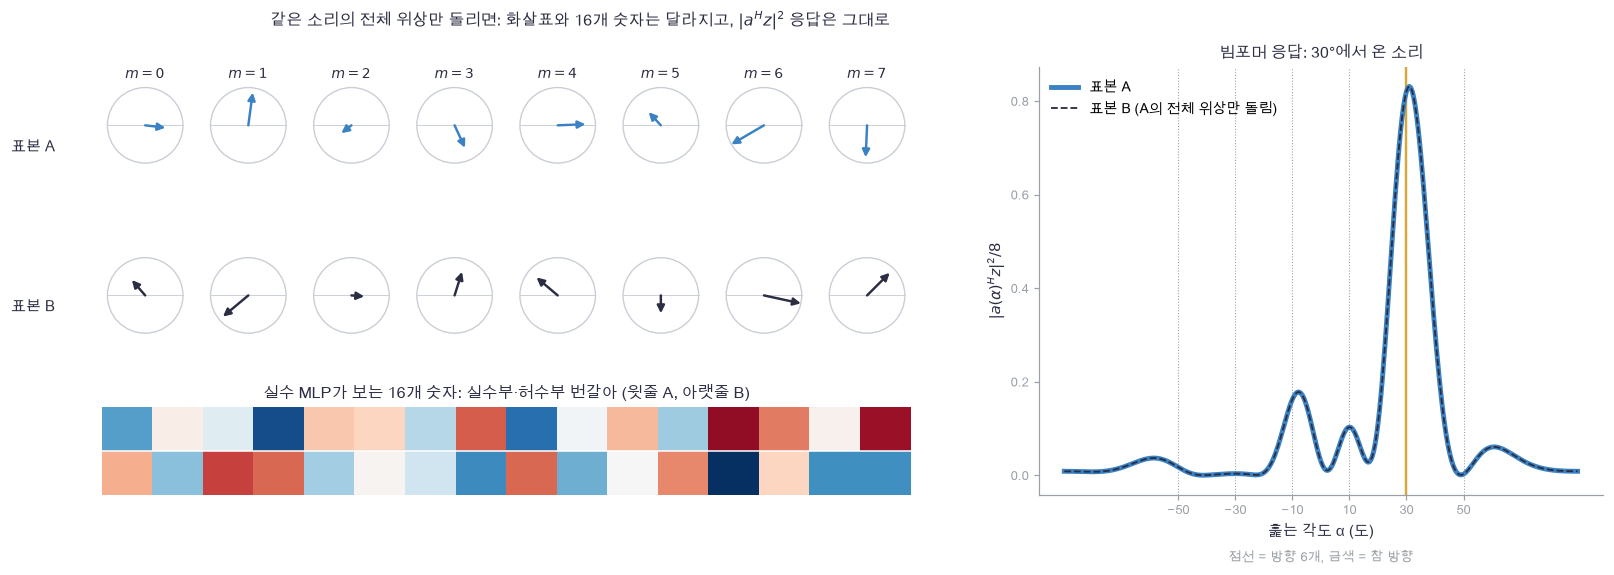

In [39]:
plot_doa_samples(sample_z, sample_real, sweep_deg, sweep_response, doa_class_deg, 30)

🔍 **확인** · 표본 B는 A의 여덟 화살표를 모두 2.4 라디안(약 137°) 돌린 것이라 시계 그림이 통째로 다르고, 실수 MLP가 보는 16개 숫자도 최대 0.912만큼 달라집니다. 그런데 빔포머 응답 $|a(\alpha)^Hz|^2/8$는 두 곡선이 겹치고(최대 차이 $4.4\times10^{-16}$) 31°에서 가장 큽니다. 마이크 잡음 때문에 봉우리가 참 방향 30°에서 조금 비켜났지만, 여섯 방향 중에서 고르면 30°가 가장 가깝습니다.
(a)는 이 응답과 같은 꼴 $|ZW|^2$을 학습하므로 A와 B를 처음부터 같은 입력으로 봅니다. 아래 구현은 데이터 생성, CE·softmax·Adam, 세 모델의 forward·backward, 학습 루프입니다.

In [40]:
def doa_steering(alpha, M=8):
    """조향 벡터를 행으로 쌓습니다: a(α)_m = e^{iπ m sin α}. alpha: (n,) 라디안 → (n, M) 복소."""
    return np.exp(1j * np.pi * np.arange(M)[None, :] * np.sin(alpha)[:, None])


def make_doa_data(n, seed, noise=0.5):
    """방향 맞히기 데이터 n개: z = s·a(α_y + δ) + e를 행마다 길이 1로. → (Z: (n, 8) 복소, y: (n,) 정수 0–5)."""
    # 쓰는 것: doa_class_deg (5절 표본 셀)
    rng = np.random.default_rng(seed)
    y = rng.integers(0, 6, n)                                           # (n,): 정답 방향 번호
    alpha = np.deg2rad(doa_class_deg[y] + rng.uniform(-4, 4, n))        # (n,): 방향 + ±4° 흔들림
    s = (rng.normal(size=n) + 1j * rng.normal(size=n)) / np.sqrt(2)     # (n,): CN(0, 1). 크기와 전체 위상이 제멋대로
    e = (rng.normal(size=(n, 8)) + 1j * rng.normal(size=(n, 8))) / np.sqrt(2) * noise   # (n, 8): CN(0, noise²)
    Z = s[:, None] * doa_steering(alpha) + e                            # (n, 8)
    return Z / np.linalg.norm(Z, axis=1, keepdims=True), y

In [41]:
def softmax(logits):
    """행마다 softmax (02번 8절). logits: (N, K) → (N, K) 확률."""
    z = np.exp(logits - logits.max(axis=1, keepdims=True))              # 행마다 최댓값을 빼 지수가 넘치지 않게
    return z / z.sum(axis=1, keepdims=True)


def ce_loss(logits, y):
    """softmax cross-entropy 평균과 logit 기울기 (02번 8절). logits: (N, K), y: (N,) → (L: 숫자, d: (N, K) = (P − T)/N)."""
    probs = softmax(logits)
    loss = -np.mean(np.log(probs[np.arange(len(y)), y] + 1e-12))
    grad = probs.copy()
    grad[np.arange(len(y)), y] -= 1                                     # 정답 자리만 1을 빼면 P − T
    return loss, grad / len(y)


def adam_step(p, grads, state, step, lr):
    """Adam 갱신 (04번 6절)을 사전의 모든 배열에. 복소 배열은 view로 실수부·허수부를 두 실수 좌표로 보고 그대로 갱신합니다.
    p, grads: 같은 키의 사전(복소 또는 실수), state: 키 → (m, v) 실수 배열, step: 1부터 세는 스텝."""
    for key in p:
        x = p[key].view(np.float64)                                     # 복소 (…, K) → 실수 (…, 2K) 보기. x를 바꾸면 p[key]가 바뀜
        g = np.ascontiguousarray(grads[key]).view(np.float64)           # g = ∂L/∂x + i ∂L/∂y 의 두 성분 = 실수 기울기
        m, v = state[key]
        m = 0.9 * m + 0.1 * g                                           # 1차 모멘트
        v = 0.999 * v + 0.001 * g ** 2                                  # 2차 모멘트: 실수부·허수부 따로
        x -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 제자리 갱신
        state[key] = (m, v)

In [42]:
def init_complex_model(seed):
    """(a) 복소 모델의 파라미터: W (8, 6) 복소, 배율 a (1,) 실수, 편향 c (6,) 실수."""
    rng = np.random.default_rng(seed)
    return {"W": (rng.normal(size=(8, 6)) + 1j * rng.normal(size=(8, 6))) * 0.3, "a": np.array([5.0]), "c": np.zeros(6)}


def complex_model_forward(Z, p):
    """(a) logits = a·|ZW|² + c. Z: (N, 8) 복소 → (logits: (N, 6), cache: (Z, Y, P))."""
    Y = Z @ p["W"]                                                      # (N, 6): 편향 없는 복소 선형층
    P = np.abs(Y) ** 2                                                  # (N, 6): |·|² 읽기. 위상을 버리고 에너지만
    return p["a"] * P + p["c"], (Z, Y, P)


def complex_model_backward(dlogits, cache, p):
    """(a)의 backward: ∂L/∂P = a·d, g_Y = 2(∂L/∂P)Y, g_W = Zᴴ g_Y, ∂L/∂a = Σ d·P, ∂L/∂c = Σ_n d.
    dlogits: (N, 6), cache: complex_model_forward의 것 → 키가 W, a, c인 기울기 사전."""
    # 쓰는 것: complex_linear_backward (3절)
    Z, Y, P = cache
    gY = 2 * (dlogits * p["a"]) * Y                                     # (N, 6): P = YȲ → g_Y = 2 (∂L/∂P) Y
    _, gW, _ = complex_linear_backward(gY, Z, p["W"])                   # (8, 6): 3절의 Zᴴ g_Y. 편향이 없으니 gb는 버림
    return {"W": gW, "a": np.array([np.sum(dlogits * P)]), "c": dlogits.sum(axis=0)}

In [43]:
def init_mlp(D, seed, H=32):
    """(b)·(c) 실수 MLP D → H → 6의 파라미터. 첫 층은 He 초기화(04번 9절)."""
    rng = np.random.default_rng(seed)
    return {"W1": rng.normal(size=(D, H)) * np.sqrt(2 / D), "b1": np.zeros(H),
            "W2": rng.normal(size=(H, 6)) * np.sqrt(1 / H), "b2": np.zeros(6)}


def mlp_forward(X, p):
    """실수 MLP: A = XW₁ + b₁, H = ReLU(A), logits = HW₂ + b₂ (03번 4절). X: (N, D) 실수 → (logits: (N, 6), cache: (X, A, H))."""
    A = X @ p["W1"] + p["b1"]
    H = np.maximum(A, 0)
    return H @ p["W2"] + p["b2"], (X, A, H)


def mlp_backward(dlogits, cache, p):
    """실수 MLP backward (03번 5절). dlogits: (N, 6) → 키가 W1, b1, W2, b2인 기울기 사전."""
    X, A, H = cache
    dA = (dlogits @ p["W2"].T) * (A > 0)                                # (N, H): ReLU 도함수
    return {"W1": X.T @ dA, "b1": dA.sum(axis=0), "W2": H.T @ dlogits, "b2": dlogits.sum(axis=0)}

In [44]:
def train_model(forward, backward, p, X, y, lr, steps=400):
    """full batch Adam 학습. forward(X, p) → (logits, cache), backward(dlogits, cache, p) → 기울기 사전.
    p를 제자리에서 갱신하고 마지막 스텝의 학습 CE를 돌려줍니다."""
    # 쓰는 것: ce_loss, adam_step (5절)
    state = {key: (np.zeros(value.view(np.float64).shape), np.zeros(value.view(np.float64).shape)) for key, value in p.items()}
    for step in range(1, steps + 1):
        logits, cache = forward(X, p)                                   # 1. forward
        loss, dlogits = ce_loss(logits, y)                              # 2. CE와 logit 기울기
        adam_step(p, backward(dlogits, cache, p), state, step, lr)      # 3. backward와 갱신
    return loss


def accuracy(forward, p, X, y):
    """정확도: logits가 가장 큰 방향이 정답과 같은 비율."""
    return float(np.mean(forward(X, p)[0].argmax(axis=1) == y))

In [45]:
# 쓰는 것: sample_a (5절 표본 셀) · make_doa_data, doa_steering, ce_loss (5절) · complex_to_real (1절)
check_Z, check_y = make_doa_data(20, seed=30)                               # (20, 8), (20,): 작은 검사용 배치
np.testing.assert_allclose(np.linalg.norm(check_Z, axis=1), 1.0)            # 검산: 표본마다 길이 1
np.testing.assert_allclose(doa_steering(np.deg2rad([30.0]))[0], sample_a)   # 검산: 30°의 조향 벡터가 표본 셀과 같음
check_complex = init_complex_model(seed=31)
check_complex["c"] = np.random.default_rng(32).normal(size=6)               # 편향도 0이 아닌 값으로
check_real = init_mlp(16, seed=33)
check_real["b1"] = np.random.default_rng(34).normal(size=32) * 0.1


def complex_scalar():
    """검사기용: 검사 배치에서 (a) 복소 모델의 CE."""
    return ce_loss(complex_model_forward(check_Z, check_complex)[0], check_y)[0]


def real_scalar():
    """검사기용: 검사 배치에서 (b) 실수 MLP의 CE."""
    return ce_loss(mlp_forward(complex_to_real(check_Z), check_real)[0], check_y)[0]


print("데이터: 행마다 길이 1, 30° 조향 벡터 일치 · 검사 배치", check_Z.shape, "· 정답", check_y[:10])

데이터: 행마다 길이 1, 30° 조향 벡터 일치 · 검사 배치 (20, 8) · 정답 [0 1 4 2 2 0 3 3 1 4]


In [46]:
# 쓰는 것: complex_numerical_gradient, complex_rel_error (3절) · complex_to_real (1절) · ce_loss, complex_model_forward, complex_model_backward (5절) · check_Z, check_y, check_complex, check_real, complex_scalar, real_scalar (5절 검사 준비 셀)
check_logits, check_cache = complex_model_forward(check_Z, check_complex)
check_grads = complex_model_backward(ce_loss(check_logits, check_y)[1], check_cache, check_complex)
model_errors = {"(a) W": complex_rel_error(check_grads["W"], complex_numerical_gradient(complex_scalar, check_complex["W"])),
                "(a) a": rel_error(check_grads["a"], numerical_gradient(complex_scalar, check_complex["a"])),
                "(a) c": rel_error(check_grads["c"], numerical_gradient(complex_scalar, check_complex["c"]))}
check_logits, check_cache = mlp_forward(complex_to_real(check_Z), check_real)
check_grads = mlp_backward(ce_loss(check_logits, check_y)[1], check_cache, check_real)
for key in check_grads:                                                     # (b)의 W1, b1, W2, b2
    model_errors[f"(b) {key}"] = rel_error(check_grads[key], numerical_gradient(real_scalar, check_real[key]))
print("모델 기울기의 상대오차:", {name: f"{error:.1e}" for name, error in model_errors.items()})
assert max(model_errors.values()) < 1e-6, "(a)의 W·a·c와 (b)의 모든 기울기 상대오차가 1e−6 아래여야 합니다"

모델 기울기의 상대오차: {'(a) W': '1.0e-09', '(a) a': '1.0e-10', '(a) c': '1.2e-09', '(b) W1': '1.7e-08', '(b) b1': '4.1e-09', '(b) W2': '4.2e-09', '(b) b2': '1.3e-09'}


🔍 **확인** · (a)의 복소 $W$는 실수부·허수부 중심차분으로, 실수 $a$, $c$와 (b)의 네 배열은 실수 중심차분으로 맞습니다. 이제 학습합니다. 아래 셀은 학습 300개로 세 모델을 한 번씩 학습하고, 학습 없는 빔포머와 함께 test 3,000개의 정확도를 봅니다.

In [47]:
# 쓰는 것: doa_class_deg (5절 표본 셀) · make_doa_data, doa_steering, init_complex_model, complex_model_forward, complex_model_backward, init_mlp, mlp_forward, mlp_backward (5절) · complex_to_real (1절)
doa_Z_test, doa_y_test = make_doa_data(3000, seed=1)                        # test 3,000개 (학습에 쓰지 않음)
doa_Z_train, doa_y_train = make_doa_data(300, seed=2)                       # 학습 300개
beam_W = doa_steering(np.deg2rad(doa_class_deg)).conj().T / np.sqrt(8)      # (8, 6): 열 k = conj(a(α_k)) / √8
beam_accuracy = float(np.mean((np.abs(doa_Z_test @ beam_W) ** 2).argmax(axis=1) == doa_y_test))
complex_p = init_complex_model(seed=3)
complex_loss = train_model(complex_model_forward, complex_model_backward, complex_p, doa_Z_train, doa_y_train, lr=0.05)
real_p = init_mlp(16, seed=4)
real_loss = train_model(mlp_forward, mlp_backward, real_p, complex_to_real(doa_Z_train), doa_y_train, lr=0.01)
magnitude_p = init_mlp(8, seed=5)
magnitude_loss = train_model(mlp_forward, mlp_backward, magnitude_p, np.abs(doa_Z_train), doa_y_train, lr=0.01)
single_accuracy = {"(a) 복소": accuracy(complex_model_forward, complex_p, doa_Z_test, doa_y_test),
                   "(b) 실수 MLP": accuracy(mlp_forward, real_p, complex_to_real(doa_Z_test), doa_y_test),
                   "(c) 크기만": accuracy(mlp_forward, magnitude_p, np.abs(doa_Z_test), doa_y_test)}
single_params = {"(a) 복소": sum(v.view(np.float64).size for v in complex_p.values()),
                 "(b) 실수 MLP": sum(v.size for v in real_p.values()), "(c) 크기만": sum(v.size for v in magnitude_p.values())}
for (name, acc), loss in zip(single_accuracy.items(), [complex_loss, real_loss, magnitude_loss]):
    print(f"{name}: 실수 파라미터 {single_params[name]} · 마지막 학습 CE {loss:.3f} · test 정확도 {acc:.3f}")
print(f"빔포머 (학습 없음): test 정확도 {beam_accuracy:.3f} · 우연 수준 1/6 = {1 / 6:.3f}")
assert single_params["(a) 복소"] == 103, "(a)의 실수 파라미터는 96 + 1 + 6 = 103이어야 합니다"

(a) 복소: 실수 파라미터 103 · 마지막 학습 CE 0.001 · test 정확도 0.857
(b) 실수 MLP: 실수 파라미터 742 · 마지막 학습 CE 0.005 · test 정확도 0.859
(c) 크기만: 실수 파라미터 486 · 마지막 학습 CE 1.296 · test 정확도 0.173
빔포머 (학습 없음): test 정확도 0.934 · 우연 수준 1/6 = 0.167


In [48]:
# 쓰는 것: doa_Z_test, doa_y_test (5절 학습 셀) · make_doa_data, init_complex_model, complex_model_forward, complex_model_backward, init_mlp, mlp_forward, mlp_backward, train_model, accuracy (5절) · complex_to_real (1절)
curve_sizes = [12, 30, 100, 300, 1000, 3000]                                # 학습 표본 수
curve_acc = {name: np.zeros((len(curve_sizes), 3)) for name in ("complex", "real", "magnitude")}   # (표본 수 6, seed 3)
for i, n in enumerate(curve_sizes):
    for seed in range(3):
        Z, y = make_doa_data(n, seed=100 + 10 * i + seed)                   # 표본 수·seed마다 새 학습 데이터
        p = init_complex_model(seed=200 + seed)
        train_model(complex_model_forward, complex_model_backward, p, Z, y, lr=0.05)
        curve_acc["complex"][i, seed] = accuracy(complex_model_forward, p, doa_Z_test, doa_y_test)
        p = init_mlp(16, seed=300 + seed)
        train_model(mlp_forward, mlp_backward, p, complex_to_real(Z), y, lr=0.01)
        curve_acc["real"][i, seed] = accuracy(mlp_forward, p, complex_to_real(doa_Z_test), doa_y_test)
        p = init_mlp(8, seed=400 + seed)
        train_model(mlp_forward, mlp_backward, p, np.abs(Z), y, lr=0.01)
        curve_acc["magnitude"][i, seed] = accuracy(mlp_forward, p, np.abs(doa_Z_test), doa_y_test)
for i, n in enumerate(curve_sizes):
    print(f"학습 {n:>4}개 · test 정확도 (seed 3개 평균) · (a) 복소 {curve_acc['complex'][i].mean():.3f}"
          f" · (b) 실수 MLP {curve_acc['real'][i].mean():.3f} · (c) 크기만 {curve_acc['magnitude'][i].mean():.3f}")

학습   12개 · test 정확도 (seed 3개 평균) · (a) 복소 0.723 · (b) 실수 MLP 0.391 · (c) 크기만 0.166
학습   30개 · test 정확도 (seed 3개 평균) · (a) 복소 0.878 · (b) 실수 MLP 0.531 · (c) 크기만 0.160
학습  100개 · test 정확도 (seed 3개 평균) · (a) 복소 0.892 · (b) 실수 MLP 0.720 · (c) 크기만 0.162
학습  300개 · test 정확도 (seed 3개 평균) · (a) 복소 0.867 · (b) 실수 MLP 0.871 · (c) 크기만 0.169
학습 1000개 · test 정확도 (seed 3개 평균) · (a) 복소 0.916 · (b) 실수 MLP 0.896 · (c) 크기만 0.172
학습 3000개 · test 정확도 (seed 3개 평균) · (a) 복소 0.930 · (b) 실수 MLP 0.913 · (c) 크기만 0.174


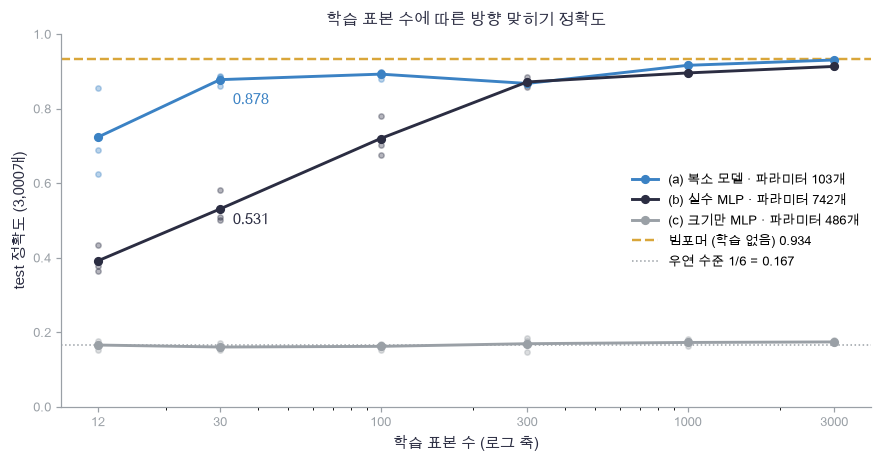

In [49]:
plot_sample_curves(curve_sizes, curve_acc["complex"], curve_acc["real"], curve_acc["magnitude"], beam_accuracy, 1 / 6,
                   list(single_params.values()))

🔍 **확인** · 학습 표본 12개에서 (a) 복소 모델은 0.723, (b) 실수 MLP는 0.391이고, 30개에서 0.878 대 0.531, 100개에서 0.892 대 0.720입니다. (b)가 (a)의 30개 수준(0.878)에 거의 닿는 것은 300개(0.871)이고, 그 뒤로는 둘이 비슷하게 올라 3,000개에서 (a) 0.930, (b) 0.913입니다. (c) 크기만 MLP는 3,000개에서도 0.174로 우연 수준 0.167 근처에 머뭅니다. 2절대로 크기에는 방향이 없기 때문입니다. 학습 없는 빔포머(금색 점선)는 0.934입니다.
(a)가 300개에서 0.867로 100개(0.892)보다 조금 낮습니다. 300개의 seed별 점 세 개가 서로 겹칠 만큼 가까워서, seed의 흔들림으로는 설명되지 않습니다. 표본 수와 상관없이 400스텝·같은 학습률로 고정했기 때문에, 파라미터 103개인 (a)가 학습 표본에 완전히 맞춰질 때까지 학습된 몫이 섞인 것으로 보입니다. 위 셀에서 학습 300개로 한 번 학습한 모델도 마지막 학습 CE가 (a) 0.001, (b) 0.005로 둘 다 학습 표본에는 거의 완전히 맞았고, test 정확도는 (a) 0.857, (b) 0.859로 비슷했습니다. 구조에 넣은 대칭은 배울 것을 줄여 줄 뿐, 학습 표본에 과하게 맞추는 것까지 막지는 않습니다. 스텝 수를 표본 수에 맞춰 고르는 실험은 이 노트북에서 하지 않습니다.
3,000개의 (a) 0.930이 빔포머 0.934와 거의 같은 것은 빔포머가 (a)가 표현할 수 있는 식 중 하나라는 앞의 설명과 어긋나지 않습니다.
(a)와 (b)는 불변 말고도 파라미터 수(103 대 742)와 식의 모양이 달라, 이 곡선만으로 불변의 몫을 떼어 낼 수는 없습니다. 노트북 끝 완성 예제에서 (a)에 복소 편향 하나만 더해 불변만 깨고 같은 학습 30개로 견줍니다.
이 비교는 이 노트북의 작은 합성 문제 하나에서, 학습률과 스텝 수를 모델마다 한 번 정해 본 결과입니다. 복소 모델이 언제나 실수 모델보다 낫다는 뜻이 아니라, **문제의 대칭(전체 위상)을 구조에 넣으면 그만큼 표본에서 배울 것이 줄어든다**는 사례입니다.

In [50]:
# 쓰는 것: doa_Z_test, doa_y_test, complex_p, real_p (5절 학습 셀) · doa_class_deg (5절 표본 셀) · complex_model_forward, mlp_forward, softmax (5절) · complex_to_real (1절)
rotate = np.exp(1j * np.random.default_rng(6).uniform(0, 2 * np.pi, size=(3000, 1)))   # (3000, 1): 표본마다 다른 전체 위상 e^{iφ_n}
complex_logits = complex_model_forward(doa_Z_test, complex_p)[0]
complex_logits_rot = complex_model_forward(rotate * doa_Z_test, complex_p)[0]
real_logits = mlp_forward(complex_to_real(doa_Z_test), real_p)[0]
real_logits_rot = mlp_forward(complex_to_real(rotate * doa_Z_test), real_p)[0]
changed = np.array([np.mean(complex_logits.argmax(axis=1) != complex_logits_rot.argmax(axis=1)),
                    np.mean(real_logits.argmax(axis=1) != real_logits_rot.argmax(axis=1))])   # (2,): 예측이 바뀐 비율
print(f"(a) 복소 · logits 최대 차이 {np.abs(complex_logits - complex_logits_rot).max():.1e} · 예측이 바뀐 비율 {changed[0]:.3f}")
print(f"(b) 실수 MLP · 확률 최대 차이 {np.abs(softmax(real_logits) - softmax(real_logits_rot)).max():.3f} · 예측이 바뀐 비율 {changed[1]:.3f}"
      f" · 돌린 입력의 정확도 {np.mean(real_logits_rot.argmax(axis=1) == doa_y_test):.3f}")
turn_angles = np.linspace(0, 2 * np.pi, 181)                                # (181,): 표본 하나를 돌리는 각도
turned = np.exp(1j * turn_angles)[:, None] * doa_Z_test[0][None, :]         # (181, 8): test 표본 0번을 φ만큼 돌린 것
turn_prob_complex = softmax(complex_model_forward(turned, complex_p)[0])[:, doa_y_test[0]]    # (181,): P(정답)
turn_prob_real = softmax(mlp_forward(complex_to_real(turned), real_p)[0])[:, doa_y_test[0]]
print(f"test 표본 0번 (정답 {doa_class_deg[doa_y_test[0]]:g}°) · P(정답)의 범위 · (a) {turn_prob_complex.max() - turn_prob_complex.min():.1e} · (b) {turn_prob_real.min():.3f}–{turn_prob_real.max():.3f}")
assert changed[0] == 0, "편향 없는 복소층 + |·|² 읽기는 전체 위상을 돌려도 예측이 하나도 바뀌지 않아야 합니다"

(a) 복소 · logits 최대 차이 1.7e-13 · 예측이 바뀐 비율 0.000
(b) 실수 MLP · 확률 최대 차이 0.997 · 예측이 바뀐 비율 0.163 · 돌린 입력의 정확도 0.849
test 표본 0번 (정답 -10°) · P(정답)의 범위 · (a) 0.0e+00 · (b) 0.420–1.000


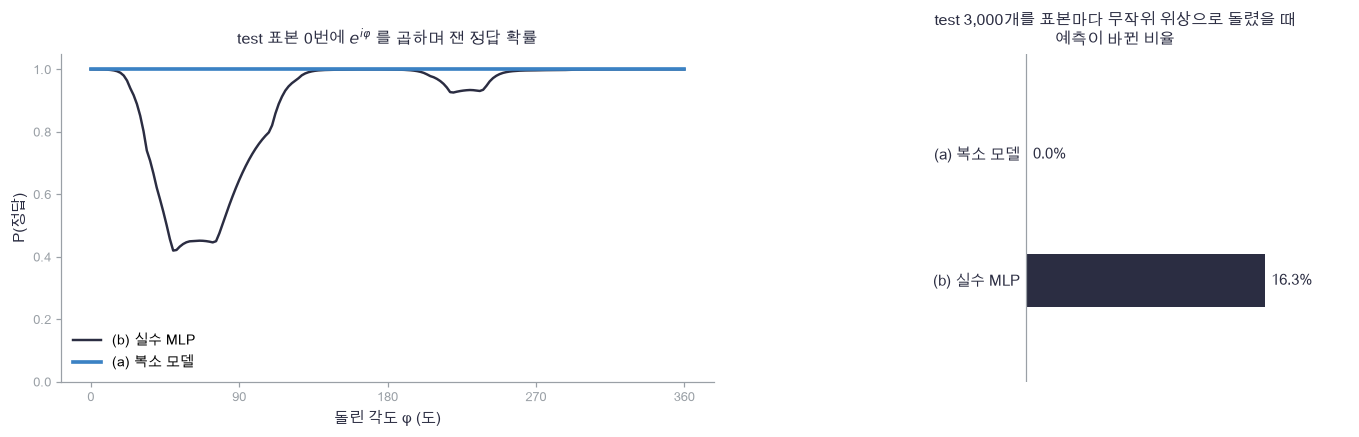

In [51]:
plot_phase_invariance(np.rad2deg(turn_angles), turn_prob_complex, turn_prob_real, changed, ["(a) 복소 모델", "(b) 실수 MLP"])

🔍 **확인** · (a)는 test 3,000개를 표본마다 다른 위상으로 돌려도 logits의 최대 차이가 $1.7\times10^{-13}$(반올림 수준)이고 예측이 하나도 바뀌지 않습니다. 왼쪽 그림에서도 test 표본 0번(정답 −10°)의 정답 확률이 모든 각도에서 한 값입니다. (b) 실수 MLP는 같은 표본을 돌리면 정답 확률이 0.420부터 1.000까지 오르내리고, test 전체에서는 예측의 16.3%가 바뀌며 돌린 입력의 정확도는 0.849입니다(돌리기 전 0.859).
(b)는 "위상만 다른 같은 소리는 같은 답"이라는 규칙을 학습 표본에서 배워야 하고, 300개로는 여섯 개 중 한 개꼴로 어긋납니다. (a)는 그 규칙이 식 $|ZW|^2$ 안에 들어 있어 배울 필요가 없습니다. 이 불변을 만든 것은 1절 끝의 "편향 없는 곱은 전체 회전과 순서를 바꿔도 같다"와 4절 끝의 $|\cdot|^2$ 읽기이고, 3절의 켤레전치 backward는 그 모델을 학습시키는 도구입니다. (a)에는 활성화가 없습니다. 4절의 modReLU는 층을 더 쌓아도 이 불변을 지키는 부품이라는 것을 아래 두 층 계산으로 확인합니다.

In [52]:
def readout_modrelu(Z, W1, b_act, W2, bias=0):
    """학습 전 두 층 모델의 |·|² 읽기: |modReLU(ZW₁ + bias; b_act) W₂|².
    Z: (N, 8) 복소, W1: (8, H) 복소, b_act: (H,) 실수, W2: (H, 6) 복소, bias: 숫자 또는 (H,) 복소 → (N, 6) 실수."""
    # 쓰는 것: modrelu_forward (4절)
    return np.abs(modrelu_forward(Z @ W1 + bias, b_act)[0] @ W2) ** 2


def readout_crelu(Z, W1, W2):
    """활성화만 CReLU로 바꾼 두 층 읽기: |CReLU(ZW₁) W₂|². 모양은 readout_modrelu와 같습니다."""
    # 쓰는 것: crelu_forward (4절)
    return np.abs(crelu_forward(Z @ W1) @ W2) ** 2

In [53]:
# 쓰는 것: doa_Z_test (5절 학습 셀) · rotate (5절 위상 셀)
deep_rng = np.random.default_rng(7)
deep_W1 = (deep_rng.normal(size=(8, 16)) + 1j * deep_rng.normal(size=(8, 16))) / 4   # (8, 16): 첫 복소층 (편향 없음)
deep_b = deep_rng.uniform(-0.5, 0.1, size=16)                                        # (16,): modReLU의 실수 편향
deep_W2 = (deep_rng.normal(size=(16, 6)) + 1j * deep_rng.normal(size=(16, 6))) / 4   # (16, 6): 둘째 복소층 (편향 없음)
deep_c = 0.3 + 0.2j                                                                  # 비교용 복소 편향
deep_Z_rot = rotate * doa_Z_test                                                     # (3000, 8): 표본마다 전체 위상을 돌린 test 입력
deep_gaps = {"편향 없음 + modReLU": np.abs(readout_modrelu(deep_Z_rot, deep_W1, deep_b, deep_W2)
                                          - readout_modrelu(doa_Z_test, deep_W1, deep_b, deep_W2)).max(),
             "편향 없음 + CReLU": np.abs(readout_crelu(deep_Z_rot, deep_W1, deep_W2) - readout_crelu(doa_Z_test, deep_W1, deep_W2)).max(),
             "복소 편향 + modReLU": np.abs(readout_modrelu(deep_Z_rot, deep_W1, deep_b, deep_W2, deep_c)
                                          - readout_modrelu(doa_Z_test, deep_W1, deep_b, deep_W2, deep_c)).max()}
print("전체 위상을 돌렸을 때 |·|² 읽기의 최대 차이:", {name: f"{gap:.1e}" for name, gap in deep_gaps.items()})
assert deep_gaps["편향 없음 + modReLU"] < 1e-12, "편향 없는 복소층 + modReLU + |·|² 읽기는 정확히 불변이어야 합니다"
assert min(deep_gaps["편향 없음 + CReLU"], deep_gaps["복소 편향 + modReLU"]) > 1e-3, "CReLU나 복소 편향을 쓰면 불변이 깨져야 합니다"

전체 위상을 돌렸을 때 |·|² 읽기의 최대 차이: {'편향 없음 + modReLU': '3.9e-16', '편향 없음 + CReLU': '8.2e-01', '복소 편향 + modReLU': '1.2e+00'}


🔍 **확인** · 층을 하나 더 쌓아도(학습 전 난수 가중치) 편향 없는 복소층 + modReLU + $|\cdot|^2$ 읽기의 차이는 $3.9\times10^{-16}$로 반올림 수준이고, 활성화를 CReLU로 바꾸면 0.82, 첫 층에 복소 편향을 더하면 1.2만큼 달라집니다. 4절의 등변 성질이 층을 거쳐 그대로 이어지고, 하나라도 등변이 아닌 부품이 끼면 끊어진다는 것을 수치로 본 것입니다. 노트북 끝의 완성 예제에서는 복소 편향을 넣은 모델을 실제로 학습해 봅니다.

### ✏️ 연습 5 · 위상을 돌려도 같은 예측인가

예측 함수 `predict`(입력 `(N, 8)` 복소 → 예측 `(N,)` 정수)가 전체 위상 회전에 얼마나 흔들리는지 재는 두 줄을 채우세요. 표본 $n$마다 각도 `phi[n]`만큼 돌린 입력 `Z_rotated`를 만들고, 돌린 입력의 예측이 원래 예측과 같은 비율 `agreement`를 돌려줍니다. 검사는 손으로 만든 두 예측 규칙과 5절에서 학습한 두 모델로 합니다.

In [54]:
def exercise_rotation_agreement(predict, Z, phi):
    """연습 5: 표본마다 전체 위상을 돌린 입력에서 예측이 유지되는 비율. predict: (N, 8) 복소 → (N,) 정수, Z: (N, 8) 복소, phi: (N,) 라디안 → 숫자."""
    assert Z.shape[0] == phi.shape[0], "각도는 표본마다 하나여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: Z_rotated = 행 n에 e^{iφ_n}을 곱한 입력 (N, 8), agreement = predict(Z_rotated)와 predict(Z)가 같은 비율
    ### 힌트: np.exp(1j * phi)[:, None]로 (N, 1)을 만들어 곱합니다 (5절 위상 셀의 rotate * doa_Z_test). 비율은 np.mean(… == …)
    raise NotImplementedError
    return agreement

In [55]:
def check_rotation_agreement(candidate):
    """손으로 만든 두 규칙(크기 argmax, 실수부 argmax)과 5절의 두 학습 모델로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: complex_p, real_p, doa_Z_test (5절 학습 셀) · changed (5절 위상 셀) · complex_model_forward, mlp_forward (5절) · complex_to_real (1절)
    example_Z = np.array([[1.0 + 0j, 0.5 + 0j], [0.2 + 0j, -1.0 + 0j]])     # (2, 2)
    half_turn = np.array([np.pi, np.pi])                                     # 둘 다 180° 돌림 → 부호만 바뀜

    def by_magnitude(Z):
        """크기가 가장 큰 자리 (위상과 무관)."""
        return np.abs(Z).argmax(axis=1)

    def by_real_part(Z):
        """실수부가 가장 큰 자리 (위상에 따라 바뀜)."""
        return Z.real.argmax(axis=1)

    np.testing.assert_allclose(candidate(by_magnitude, example_Z, half_turn), 1.0)   # 검산: 크기는 돌려도 그대로
    np.testing.assert_allclose(candidate(by_real_part, example_Z, half_turn), 0.0)   # 검산: [0, 0] → [1, 1], 둘 다 바뀜

    def complex_predict(Z):
        """5절의 학습된 (a) 복소 모델의 예측."""
        return complex_model_forward(Z, complex_p)[0].argmax(axis=1)

    def real_predict(Z):
        """5절의 학습된 (b) 실수 MLP의 예측."""
        return mlp_forward(complex_to_real(Z), real_p)[0].argmax(axis=1)

    test_phi = np.random.default_rng(6).uniform(0, 2 * np.pi, size=3000)     # 5절 위상 셀과 같은 각도
    np.testing.assert_allclose(candidate(complex_predict, doa_Z_test, test_phi), 1.0)          # 검산: (a)는 모두 유지
    np.testing.assert_allclose(candidate(real_predict, doa_Z_test, test_phi), 1 - changed[1])  # 검산: (b)는 5절에서 잰 만큼 바뀜
    print("위상 회전과 예측: 손계산·5절의 두 모델과 일치합니다.")

run_check(check_rotation_agreement, exercise_rotation_agreement, hint="Z_rotated = Z * np.exp(1j * phi)[:, None], agreement = np.mean(predict(Z_rotated) == predict(Z))")

☐ exercise_rotation_agreement: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: Z_rotated = Z * np.exp(1j * phi)[:, None], agreement = np.mean(predict(Z_rotated) == predict(Z))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
Z_rotated = Z * np.exp(1j * phi)[:, None]
agreement = np.mean(predict(Z_rotated) == predict(Z))
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 복소 가중치를 실수 블록으로 펼치기 (1절)

복소 가중치 `W` `(D, K)`를 실수부·허수부가 번갈아 놓인 실수 행렬 `R` `(2D, 2K)`로 펼칩니다. 대각선 자리 두 곳($a$)은 써 두었습니다. 나머지 두 자리, 곧 입력 실수부 → 출력 허수부에 $b$, 입력 허수부 → 출력 실수부에 $-b$를 넣는 두 줄을 채우세요. 부호를 바꾸면 복소 행렬곱과 달라져 검사가 잡습니다.

In [56]:
def exercise_real_block(W):
    """연습 A: 복소 W: (D, K) → 번갈아 펼친 실수 R: (2D, 2K). W_dk = a + ib 자리마다 2×2 블록 [[a, b], [−b, a]]."""
    D, K = W.shape
    R = np.zeros((2 * D, 2 * K))
    R[0::2, 0::2] = W.real                                  # 입력 실수부 → 출력 실수부: a
    R[1::2, 1::2] = W.real                                  # 입력 허수부 → 출력 허수부: a
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 짝수 행·홀수 열(입력 실수부 → 출력 허수부)에 b = Im W, 홀수 행·짝수 열(입력 허수부 → 출력 실수부)에 −b
    ### 힌트: 1절 real_block의 가운데 두 줄입니다. (x + iy)(a + ib) = (ax − by) + i(bx + ay)에서 x 옆의 b는 허수부로, y 옆의 −b는 실수부로 갑니다
    raise NotImplementedError
    return R

In [57]:
def check_real_block(candidate):
    """(1, 1) 손계산과 1절의 복소 행렬곱(lin_X, block_W)으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: complex_to_real, real_block (1절) · block_W (1절 블록 셀) · lin_X (1절 검산 셀)
    np.testing.assert_allclose(candidate(np.array([[1 + 2j]])), [[1, 2], [-2, 1]])   # 검산: a = 1, b = 2
    R = candidate(block_W)
    assert R.shape == (8, 6), f"R은 (2D, 2K) = (8, 6)이어야 하는데 {np.shape(R)}입니다"
    np.testing.assert_allclose(complex_to_real(lin_X) @ R, complex_to_real(lin_X @ block_W))   # 검산: 펼친 곱 = 복소 행렬곱
    np.testing.assert_allclose(R, real_block(block_W))      # 검산: 1절 real_block과 같음
    print("실수 블록 펼치기: 손계산·복소 행렬곱과 일치합니다.")

run_check(check_real_block, exercise_real_block, hint="R[0::2, 1::2] = W.imag, R[1::2, 0::2] = -W.imag")

☐ exercise_real_block: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: R[0::2, 1::2] = W.imag, R[1::2, 0::2] = -W.imag


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
R[0::2, 1::2] = W.imag
R[1::2, 0::2] = -W.imag
```

</details>

### ✏️ 연습 B · $|\cdot|^2$ 읽기의 기울기 (3·5절)

복소 출력 `Y` `(N, K)`의 에너지 $P=|Y|^2$를 읽는 층에서, 상류 기울기 `dP` $=\partial L/\partial P$ `(N, K)`(실수)를 받아 `Y`의 기울기 `gY`를 만드는 한 줄을 채우세요. 3절의 관례 $g=2\,\partial L/\partial\bar Y$를 씁니다.

In [58]:
def exercise_power_grad(Y, dP):
    """연습 B: P = |Y|² 읽기의 backward. Y: (N, K) 복소, dP = ∂L/∂P: (N, K) 실수 → g_Y: (N, K) 복소."""
    assert Y.shape == dP.shape, "Y와 dP의 모양이 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 원소별 g_Y = 2 · (∂L/∂P) · Y
    ### 힌트: P = YȲ에서 ∂P/∂Ȳ = Y이고, 3절의 g = 2 ∂L/∂Ȳ입니다. 5절 complex_model_backward의 gY 줄에서 a를 뺀 것
    raise NotImplementedError
    return gY

In [59]:
def check_power_grad(candidate):
    """(1, 1) 손계산과 실수부·허수부 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: complex_numerical_gradient, complex_rel_error (3절)
    np.testing.assert_allclose(candidate(np.array([[1 + 2j]]), np.array([[0.5]])), [[1 + 2j]])   # 검산: 2·0.5·(1 + 2i)
    rng_check = np.random.default_rng(61)
    Y = rng_check.normal(size=(4, 3)) + 1j * rng_check.normal(size=(4, 3))
    dP = rng_check.normal(size=(4, 3))

    def power_scalar():
        """검사기용: L = Σ dP · |Y|²."""
        return float(np.sum(dP * np.abs(Y) ** 2))

    gY = candidate(Y, dP)
    assert complex_rel_error(gY, complex_numerical_gradient(power_scalar, Y)) < 1e-6, "실수부·허수부 중심차분과 같아야 합니다"
    print("|·|² 읽기의 기울기: 손계산·중심차분과 일치합니다.")

run_check(check_power_grad, exercise_power_grad, hint="gY = 2 * dP * Y")

☐ exercise_power_grad: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: gY = 2 * dP * Y


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
gY = 2 * dP * Y
```

</details>

### ✏️ 연습 C · modReLU 편향의 기울기 (4절)

modReLU $f(z)=\mathrm{ReLU}(|z|+b)\,z/|z|$의 실수 편향 `b` `(H,)`의 기울기를 만드는 한 줄을 채우세요. $\partial f/\partial b=z/|z|$가 복소수이므로 3절의 "실수 파라미터가 복소 출력을 거치면" 규칙 $\sum_n\mathrm{Re}(g_w\,\overline{\partial f/\partial b})$를 켜진 자리에서만 씁니다.

In [60]:
def exercise_modrelu_bias_grad(g_out, z, b):
    """연습 C: modReLU 실수 편향의 기울기. g_out: (N, H) 복소 (g_w), z: (N, H) 복소, b: (H,) 실수 → (H,) 실수."""
    r = np.abs(z)                                           # (N, H): 크기
    on = (r + b) > 0                                        # (N, H): 켜진 자리
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: g_b = Σ_n Re(g_w · conj(z/|z|)), 켜진 자리만 더함 (모양 (H,))
    ### 힌트: 4절 modrelu_backward의 g_b 줄입니다. 켜진 자리는 on을 곱하고, 표본 축(axis=0)으로 더합니다
    raise NotImplementedError
    return g_b

In [61]:
def check_modrelu_bias_grad(candidate):
    """(1, 2) 손계산, 4절 modrelu_backward, 실수 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: modrelu_forward, modrelu_backward (4절) · act_z, act_b, act_G (4절 검산 셀)
    example = candidate(np.array([[1 + 0j, 2 + 0j]]), np.array([[3 + 4j, 0.1 + 0j]]), np.array([-1.0, -0.5]))
    np.testing.assert_allclose(example, [0.6, 0.0], atol=1e-12)   # 검산: Re(1·(0.6 − 0.8i)) = 0.6, 둘째는 |z| + b < 0이라 0
    reference = modrelu_backward(act_G, modrelu_forward(act_z, act_b)[1])[1]
    np.testing.assert_allclose(candidate(act_G, act_z, act_b), reference, atol=1e-8)   # 검산: 4절 modrelu_backward의 g_b
    b_copy = act_b.copy()                                   # 검사 안에서만 흔들 복사본

    def bias_scalar():
        """검사기용: L = Σ Re(Ḡ·modReLU(z; b))."""
        return float(np.real(np.vdot(act_G, modrelu_forward(act_z, b_copy)[0])))

    assert rel_error(candidate(act_G, act_z, b_copy), numerical_gradient(bias_scalar, b_copy)) < 1e-6, "b의 중심차분과 같아야 합니다"
    print("modReLU 편향의 기울기: 손계산·modrelu_backward·중심차분과 일치합니다.")

run_check(check_modrelu_bias_grad, exercise_modrelu_bias_grad, hint="g_b = np.sum(np.real(g_out * np.conj(z / r)) * on, axis=0)")

☐ exercise_modrelu_bias_grad: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: g_b = np.sum(np.real(g_out * np.conj(z / r)) * on, axis=0)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
g_b = np.sum(np.real(g_out * np.conj(z / r)) * on, axis=0)
```

</details>

### ✏️ 연습 D · 빔포머 logits 한 줄 (5절)

신호 `Z` `(N, 8)`와 방향 각도 `angles` `(K,)`(라디안)에서 빔포머 logits $|a(\alpha_k)^Hz_n|^2/8$ `(N, K)`를 만드는 한 줄을 채우세요. 조향 벡터를 행으로 쌓은 `A` `(K, 8)`는 써 두었습니다. 켤레를 빼먹으면 방향이 뒤집혀 검사가 잡습니다.

In [62]:
def exercise_beamformer_logits(Z, angles):
    """연습 D: 빔포머 logits_k = |a(α_k)ᴴ z|² / 8. Z: (N, 8) 복소, angles: (K,) 라디안 → (N, K) 실수."""
    A = np.exp(1j * np.pi * np.arange(8)[None, :] * np.sin(angles)[:, None])   # (K, 8): 행 k = 조향 벡터 a(α_k)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: logits = |Z @ Aᴴ|² / 8. 칸 (n, k)가 a(α_k)ᴴ z_n의 제곱 크기를 8로 나눈 값 (모양 (N, K))
    ### 힌트: 5절 표본 셀의 sweep_response 줄과 같습니다. 켤레전치 A.conj().T (8, K)를 오른쪽에 곱합니다
    raise NotImplementedError
    return logits

In [63]:
def check_beamformer_logits(candidate):
    """잡음 없는 30° 신호의 손계산과 5절의 빔포머 정확도로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: doa_Z_test, doa_y_test, beam_W, beam_accuracy (5절 학습 셀) · doa_class_deg (5절 표본 셀)
    clean = np.exp(1j * np.pi * np.arange(8) * 0.5)[None, :] / np.sqrt(8)   # (1, 8): 30°(sin = 0.5)의 조향 벡터 / √8
    logits = candidate(clean, np.deg2rad([30.0, -30.0]))
    np.testing.assert_allclose(logits, [[1.0, 0.0]], atol=1e-12)   # 검산: 같은 방향은 |8/√8|²/8 = 1, −30°는 Σ e^{iπm} = 0
    test_logits = candidate(doa_Z_test, np.deg2rad(doa_class_deg))
    np.testing.assert_allclose(test_logits, np.abs(doa_Z_test @ beam_W) ** 2)   # 검산: 5절 beam_W의 |ZW|²
    np.testing.assert_allclose(np.mean(test_logits.argmax(axis=1) == doa_y_test), beam_accuracy)   # 검산: 5절 빔포머 정확도
    print("빔포머 logits: 손계산·5절 빔포머와 일치합니다.")

run_check(check_beamformer_logits, exercise_beamformer_logits, hint="logits = np.abs(Z @ A.conj().T) ** 2 / 8")

☐ exercise_beamformer_logits: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: logits = np.abs(Z @ A.conj().T) ** 2 / 8


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
logits = np.abs(Z @ A.conj().T) ** 2 / 8
```

</details>

### 🔍 완성 예제 · 복소 편향 하나를 더하면

5절의 (a)에 복소 편향 $b$ $(6,)$ 하나를 더한 $\mathrm{logits}=a\,|ZW+b|^2+c$를 같은 학습 300개·같은 초기 $W$·같은 설정으로 학습하고, 5절 표본 수 곡선의 학습 30개(같은 데이터·같은 초기값, seed 3개)로도 학습합니다. 식이 표현할 수 있는 것은 오히려 늘었지만, $|e^{i\varphi}ZW+b|^2\neq|ZW+b|^2$라 구조로 보장되던 위상 불변은 사라집니다. backward는 3절 선형층의 $g_b=\sum_ng_{Y,n}$ 한 줄이 늘 뿐입니다. 먼저 중심차분으로 확인하고, 학습 뒤 test 정확도와 "위상을 돌리면 예측이 바뀐 비율"을 (a)와 견줍니다. 파라미터 수와 식이 거의 같고 불변 하나만 다른 두 모델이라, 5절에서 떼어 내지 못한 "불변의 몫"을 볼 수 있습니다.

In [64]:
def biased_model_forward(Z, p):
    """완성 예제: 복소 편향을 더한 모델 logits = a·|ZW + b|² + c. Z: (N, 8) 복소, p: W, b (6,) 복소, a, c → (logits: (N, 6), cache)."""
    Y = Z @ p["W"] + p["b"]                                             # (N, 6): 편향 있는 복소 선형층
    P = np.abs(Y) ** 2
    return p["a"] * P + p["c"], (Z, Y, P)


def biased_model_backward(dlogits, cache, p):
    """(a)의 backward에 g_b = Σ_n g_Y 를 더합니다. → 키가 W, b, a, c인 기울기 사전."""
    # 쓰는 것: complex_linear_backward (3절)
    Z, Y, P = cache
    gY = 2 * (dlogits * p["a"]) * Y                                     # (N, 6): 5절과 같은 g_Y (Y에 b가 들어 있을 뿐)
    _, gW, gb = complex_linear_backward(gY, Z, p["W"])                  # 이번에는 gb도 씀
    return {"W": gW, "b": gb, "a": np.array([np.sum(dlogits * P)]), "c": dlogits.sum(axis=0)}

In [65]:
# 쓰는 것: check_Z, check_y (5절 검사 준비 셀) · init_complex_model, ce_loss (5절) · complex_numerical_gradient, complex_rel_error (3절)
bias_rng = np.random.default_rng(62)
biased_check = init_complex_model(seed=31)
biased_check["b"] = (bias_rng.normal(size=6) + 1j * bias_rng.normal(size=6)) * 0.3   # (6,) 복소 편향 (검사용 난수)


def biased_scalar():
    """검사기용: 검사 배치에서 편향 모델의 CE."""
    return ce_loss(biased_model_forward(check_Z, biased_check)[0], check_y)[0]


biased_logits, biased_cache = biased_model_forward(check_Z, biased_check)
biased_grads = biased_model_backward(ce_loss(biased_logits, check_y)[1], biased_cache, biased_check)
biased_errors = {key: complex_rel_error(biased_grads[key], complex_numerical_gradient(biased_scalar, biased_check[key])) for key in ("W", "b")}
print("편향 모델의 복소 기울기 상대오차:", {key: f"{error:.1e}" for key, error in biased_errors.items()})
assert max(biased_errors.values()) < 1e-6, "편향 모델의 W·b 기울기 상대오차가 1e−6 아래여야 합니다"

편향 모델의 복소 기울기 상대오차: {'W': '8.5e-10', 'b': '2.6e-10'}


In [66]:
# 쓰는 것: doa_Z_train, doa_y_train, doa_Z_test, doa_y_test, single_accuracy (5절 학습 셀) · rotate, changed (5절 위상 셀) · init_complex_model, train_model (5절)
biased_p = init_complex_model(seed=3)                                       # 5절 (a)와 같은 초기 W, a, c
biased_p["b"] = np.zeros(6, dtype=complex)
biased_loss = train_model(biased_model_forward, biased_model_backward, biased_p, doa_Z_train, doa_y_train, lr=0.05)
biased_test = biased_model_forward(doa_Z_test, biased_p)[0].argmax(axis=1)
biased_rotated = biased_model_forward(rotate * doa_Z_test, biased_p)[0].argmax(axis=1)
print(f"편향 모델 · 마지막 학습 CE {biased_loss:.3f} · 학습된 |b| {np.abs(biased_p['b']).round(3)}")
print(f"test 정확도 · (a) {single_accuracy['(a) 복소']:.3f} → 편향 모델 {np.mean(biased_test == doa_y_test):.3f} (돌린 입력 {np.mean(biased_rotated == doa_y_test):.3f})")
print(f"위상을 돌리면 예측이 바뀐 비율 · (a) {changed[0]:.3f} → 편향 모델 {np.mean(biased_test != biased_rotated):.3f}")

편향 모델 · 마지막 학습 CE 0.001 · 학습된 |b| [0.273 0.592 0.623 0.355 0.405 0.481]
test 정확도 · (a) 0.857 → 편향 모델 0.857 (돌린 입력 0.853)
위상을 돌리면 예측이 바뀐 비율 · (a) 0.000 → 편향 모델 0.101


In [67]:
# 쓰는 것: curve_sizes, curve_acc (5절 표본 수 셀) · doa_Z_test, doa_y_test (5절 학습 셀) · rotate (5절 위상 셀) · make_doa_data, init_complex_model, train_model (5절)
small_i = 1                                                                 # curve_sizes[1] = 학습 30개
small_acc, small_changed = np.zeros(3), np.zeros(3)                         # (seed 3,): 편향 모델의 test 정확도, 위상을 돌리면 예측이 바뀐 비율
for seed in range(3):
    Z, y = make_doa_data(curve_sizes[small_i], seed=100 + 10 * small_i + seed)   # 5절 표본 수 셀의 학습 30개와 같은 데이터
    p = init_complex_model(seed=200 + seed)                                 # 5절 표본 수 셀의 (a)와 같은 초기 W, a, c
    p["b"] = np.zeros(6, dtype=complex)
    train_model(biased_model_forward, biased_model_backward, p, Z, y, lr=0.05)
    small_pred = biased_model_forward(doa_Z_test, p)[0].argmax(axis=1)
    small_acc[seed] = np.mean(small_pred == doa_y_test)
    small_changed[seed] = np.mean(small_pred != biased_model_forward(rotate * doa_Z_test, p)[0].argmax(axis=1))
print(f"학습 {curve_sizes[small_i]}개 · 편향 모델의 실수 파라미터 {sum(v.view(np.float64).size for v in p.values())} (a는 103)")
print(f"test 정확도 (seed 3개 평균) · (a) {curve_acc['complex'][small_i].mean():.3f} → 편향 모델 {small_acc.mean():.3f}")
print(f"위상을 돌리면 예측이 바뀐 비율 · 편향 모델 seed별 {np.round(small_changed, 3)} · 평균 {small_changed.mean():.3f}")

학습 30개 · 편향 모델의 실수 파라미터 115 (a는 103)
test 정확도 (seed 3개 평균) · (a) 0.878 → 편향 모델 0.732
위상을 돌리면 예측이 바뀐 비율 · 편향 모델 seed별 [0.331 0.264 0.233] · 평균 0.276


🔍 **확인** · 복소 편향 $b$를 더해도 $W$와 $b$의 기울기가 실수부·허수부 중심차분과 맞습니다. 학습 300개에서 0으로 시작한 $b$는 학습 뒤 크기가 0.273–0.623이 되었고, test 정확도는 (a)와 같은 0.857입니다. 그런데 test 입력의 위상을 표본마다 돌리면 (a)는 예측이 하나도 바뀌지 않았던 것과 달리 편향 모델은 10.1%가 바뀝니다(돌린 입력의 정확도 0.853).
학습 30개에서는 차이가 정확도에도 나타납니다. seed 3개 평균으로 (a) 0.878, 편향 모델 0.732이고, 편향 모델은 위상을 돌리면 예측의 27.6%가 바뀝니다. 실수 파라미터가 103개와 115개로 거의 같고 식도 편향 한 항만 다른 두 모델에서 불변 하나가 이만큼의 차이를 낸 것이라, 5절의 "적은 표본으로 충분함"이 불변에서 온다는 것을 더 직접 보여 줍니다.
표본이 300개쯤 되면 편향 모델도 규칙을 대부분 배워 정확도 한 숫자로는 같아 보이지만, 편향 하나가 "위상만 다른 같은 소리는 같은 답"이라는 보장을 없앤 것은 그대로입니다. 그 보장이 필요한 문제라면 어떤 부품이 등변인지를 정확도와 따로 검산해야 합니다.

### 📎 대칭을 구조에 넣는 방법을 연결하기

| 노트북 | 입력에 가하는 변환 | 등변인 부품 | 불변으로 만드는 읽기 |
|---|---|---|---|
| 05·05b CNN | 옆으로 옮기기 | stride 1 합성곱 | 전역 풀링: 특성 맵의 모든 위치를 평균이나 최댓값 하나로 줄이기 (05b의 2×2 풀링·완전 연결층은 불변에 **가까울** 뿐) |
| 10 GNN | 노드 번호 바꾸기 | 모든 노드에 같은 message passing | 노드 평균 readout |
| 10b CVNN | 전체 위상 돌리기 $z\mapsto e^{i\varphi}z$ | 편향 없는 복소층, modReLU | $\lvert\cdot\rvert^2$ 읽기 |

세 경우 모두 "문제의 답이 바뀌지 않는 변환"을 먼저 찾고, 그 변환과 순서를 바꿔도 되는(등변) 부품으로 층을 쌓은 뒤, 마지막에 변환을 지우는(불변) 읽기를 둡니다. 부품 하나가 등변이 아니면(CReLU, 복소 편향) 보장은 끊어지고, 그 몫을 데이터에서 배워야 합니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 복소수 곱이 왜 "돌리고 늘리기"이고 복소 선형층이 같은 크기의 실수층보다 제약된 층인지, 마이크 신호의 크기만으로 방향을 알 수 없는 이유를 말할 수 있나요? → 1·2절
- **수식:** $g=\partial L/\partial x+i\,\partial L/\partial y=2\,\partial L/\partial\bar z$에서 출발해 복소 선형층의 $g_W=X^Hg_Z$, $|\cdot|^2$ 읽기의 $g_Y=2(\partial L/\partial P)Y$, modReLU의 두 Wirtinger 도함수를 쓸 수 있나요? → 3·4절
- **구현:** 복소 파라미터를 실수부·허수부 중심차분으로 검산하고, `X.conj().T`를 빼먹은 오답을 검산으로 잡고, Adam을 실수 좌표로 적용해 복소 모델을 학습할 수 있나요? → 3·5절
- **변형:** 활성화를 CReLU로 바꾸거나 복소 편향을 넣었을 때 위상 불변이 깨지는지 수치로 확인하고, 실수 MLP와 학습 표본 수별로 비교하는 실험을 설계할 수 있나요? → 4·5절

기본 아키텍처 05–10b를 마쳤습니다. 다음은 [11 · 투영·공분산·SVD·PCA](../02_연결/11_linear_algebra.ipynb)입니다. 구조가 아니라 학습 목적과 표현을 다루는 연결 기초로 넘어갑니다. 11번 1절의 내적은 이 노트북의 $a^Hz$에서 켤레를 뺀 실수판입니다.

📎 modReLU는 [Arjovsky, Shah, Bengio의 Unitary Evolution Recurrent Neural Networks](https://arxiv.org/abs/1511.06464)에서, 복소 합성곱·정규화·초기화를 묶은 설계는 [Trabelsi 등의 Deep Complex Networks](https://arxiv.org/abs/1705.09792)에서, 실수 손실의 복소 기울기(CR-calculus, Wirtinger)는 [Kreutz-Delgado의 The Complex Gradient Operator and the CR-Calculus](https://arxiv.org/abs/0906.4835)에서 자세히 볼 수 있습니다. 위상과 크기를 바꾼 복원 실험은 Oppenheim·Lim(1981)의 "The importance of phase in signals"(Proceedings of the IEEE)가 널리 알린 것입니다. 이 노트북의 방향 맞히기는 교육용 합성 문제이며, 논문 결과의 재현 실험은 아닙니다.